In [1]:
%cd ..

/blue/npadillacoreano/mcum/SocialMemEphys/diff_fam_social_memory_ephys


In [2]:
import os 
import sys
import pickle
import numpy as np
from spike.spike_analysis.spike_collection import SpikeCollection
import spike.spike_analysis.decoders as decoders 
import decodanda
import matplotlib.pyplot as plt
from decodanda import Decodanda, generate_synthetic_data, plot_perfs_null_model
import spike.spike_analysis.population_analysis as pop

In [3]:
rew_comp_spikes = SpikeCollection.load_collection(r"/blue/npadillacoreano/share/reward_comp_extention/Phy_rce2_rce3/spike_collection.json/spike_collection.json")

In [37]:
rew_comp_spikes.analyze(timebin = 50, ignore_freq = 0.5)

Your event dictionary keys are different across recordings.
Please double check them:
20240320_142408_alone_comp_subj_3-3_t5b5_merged.rec keys: dict_keys(['alone_rewarded', 'alone_rewarded_baseline', 'high_comp', 'high_comp_lose', 'high_comp_lose_baseline', 'high_comp_tie', 'high_comp_win', 'high_comp_win_baseline', 'lose', 'low_comp', 'low_comp_lose', 'low_comp_lose_baseline', 'low_comp_win', 'low_comp_win_baseline', 'overall_pretone', 'win'])
20230613_105657_standard_comp_to_training_D2_subj_1-1_t1b2L_box1_merged.rec keys: dict_keys(['alone_rewarded', 'alone_rewarded_baseline', 'high_comp', 'high_comp_lose', 'high_comp_lose_baseline', 'high_comp_win', 'high_comp_win_baseline', 'lose', 'low_comp', 'low_comp_lose', 'low_comp_lose_baseline', 'low_comp_win', 'low_comp_win_baseline', 'win'])
20230621_111240_standard_comp_to_omission_D5_subj_1-4_t3b3L_box1_merged.rec keys: dict_keys(['alone_rewarded', 'alone_rewarded_baseline', 'high_comp', 'high_comp_lose', 'high_comp_lose_baseline', 'hig

In [38]:
def _smooth_pca(data, window):                                                                                                                      
    if window is None or window <= 1:                                                                                                                 
        return data                                                                                                                                   
    kernel = np.ones(window) / window                                                                                                                 
    return np.column_stack([np.convolve(data[:, c], kernel, mode='same') for c in range(data.shape[1])])                                              


def plot_pca_results_3d(pca_result, title, colors, azim, elev, save=False, plot_range=None, smooth_window=None):                                      
    event_lengths = int(                                                                                                                              
      (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin                                      
    )                                                                                                                                                 
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin                                                                                    
    post_window = pca_result.post_window * 1000 / pca_result.timebin                                                                                  
    pc_var = pca_result.explained_variance                                                                                                            
    PCA_key = pca_result.labels                                                                                                                       
    PCA_matrix = pca_result.transformed_data                                                                                                        

    # Bin range to plot (relative to chunk start)                                                                                                   
    if plot_range is not None:                                                                                                                        
        plot_start = max(0, int(pre_window + plot_range[0] * 1000 / pca_result.timebin))                                                              
        plot_end = min(event_lengths, int(pre_window + plot_range[1] * 1000 / pca_result.timebin))                                                    
    else:                                                                                                                                             
        plot_start, plot_end = 0, event_lengths                                                                                                       

    # Marker positions relative to chunk start
    onset_rel = int(pre_window - 1)                                                                                                                   
    end_rel = int(event_end - 1)                                                                                                                      
    post_rel = event_lengths - 1

    col_counter = 0                                                                                                                                 
    fig = plt.figure(figsize=(8, 8))                                                                                                                  
    ax = fig.add_subplot(111, projection="3d")                                                                                                        

    for i in range(0, len(PCA_key), event_lengths):                                                                                                   
        event_label = PCA_key[i]                                                                                                                    
        chunk = _smooth_pca(PCA_matrix[i + plot_start : i + plot_end, :], smooth_window)                                                              

        ax.plot3D(chunk[:, 0], chunk[:, 1], chunk[:, 2],                                                                                              
                label=event_label, color=colors[col_counter], linewidth=5, alpha=0.8)                                                               

        end_in_post = pca_result.post_window > 0 and (                                                                                                                                    
            plot_range is None or plot_range[1] > pca_result.event_length                                                                                                               
            )                                                                                                                                                                                 

        # Square (pre-event): only when range starts before onset                                                                                                                         
        if plot_range is None or plot_range[0] < 0:                                                                                                                                     
            ax.scatter(chunk[0, 0], chunk[0, 1], chunk[0,2],
                 marker="s", s=200, c="w", edgecolors=colors[col_counter], zorder=2)                                                                                                

        # Triangle (onset): always — snapped to chunk[0] if range starts after onset                                                                                                      
        onset_idx = max(0, onset_rel - plot_start)                                                                                                                                      
        ax.scatter(chunk[onset_idx, 0], chunk[onset_idx, 1], chunk[onset_idx,2],                                                                                                                              
         marker="^", s=300, c="w", edgecolors=colors[col_counter], zorder=3)                                                                                                  

        # Circle (event end): at actual event end if in range, else at chunk[-1] as fallback                                                                                              
        if plot_start <= end_rel < plot_end:                                                                                                                                              
            ax.scatter(chunk[end_rel - plot_start, 0], chunk[end_rel - plot_start, 1], chunk[end_rel - plot_start,2],                                                                                                    
                 marker="o", s=200, c="w", edgecolors=colors[col_counter], zorder=4)                                                                                              
        elif not end_in_post:                                                                                                                                                             
            ax.scatter(chunk[-1, 0], chunk[-1, 1], chunk[-1,1],
                 marker="o", s=200, c="w", edgecolors=colors[col_counter], zorder=4)                                                                                                

        # Diamond (post-window): always at chunk[-1] when range extends into post-window
        if end_in_post:                                                                                                                                                                   
            ax.scatter(chunk[-1, 0], chunk[-1, 1], chunk[-1,1],                                                                                                                                      
                 marker="D", s=200, c="w", edgecolors=colors[col_counter], zorder=5)                                                          

        col_counter += 1                                                                                                                              

    ax.legend(loc="upper left", bbox_to_anchor=(1, .5), frameon=False, fontsize=14)                                                                   
    ax.view_init(azim=azim, elev=elev)
    ax.set_title(f"{title}", fontsize=24, y=1)                                                                                                        
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% variance)", fontsize=16, labelpad=-10)                                                                  
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% variance)", fontsize=16, labelpad=-10)                                                                  
    ax.set_zlabel(f"PC3 ({pc_var[2]*100:.1f}% variance)", fontsize=16, labelpad=-10)                                                                  
    ax.set_xticklabels([])                                                                                                                            
    ax.set_yticklabels([])                                                                                                                            
    ax.set_zticklabels([])                                                                                                                            
    ax.yaxis.pane.set_alpha(0.9)                                                                                                                    
    ax.xaxis.pane.set_alpha(0.9)                                                                                                                      
    ax.zaxis.pane.set_alpha(0.9)
    plt.tight_layout()                                                                                                                                
    if save:                                                                                                                                        
        plt.savefig(f'{title}.png', dpi=600, transparent=True, bbox_inches='tight')                                                                   
    plt.show()                                                                                                                                      


def plot_pca_results_2d(pca_result, title, colors, legend_spot, custom_legend_labels=None, save=False,
                        plot_range=None, smooth_window=None, mark_time = None):          
    event_lengths = int(                                                                                                                              
      (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin                                      
    )                                                                                                                                                 
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin                                                                                    
    post_window = pca_result.post_window * 1000 / pca_result.timebin                                                                                
    pc_var = pca_result.explained_variance                                                                                                            
    PCA_key = pca_result.labels                                                                                                                       
    PCA_matrix = pca_result.transformed_data

    # Bin range to plot (relative to chunk start)                                                                                                   
    if plot_range is not None:
        plot_start = max(0, int(pre_window + plot_range[0] * 1000 / pca_result.timebin))                                                              
        plot_end = min(event_lengths, int(pre_window + plot_range[1] * 1000 / pca_result.timebin))
    else:                                                                                                                                             
        plot_start, plot_end = 0, event_lengths                                                                                                     

    # Marker positions relative to chunk start                                                                                                      
    onset_rel = int(pre_window - 1)
    end_rel = int(event_end - 1)
    post_rel = event_lengths - 1                                                                                                                      

    fig = plt.figure(figsize=(8, 6))                                                                                                                  
    ax = fig.add_subplot(111)                                                                                                                       
    legend_handles = []

    if custom_legend_labels is None:
        unique_labels = []                                                                                                                            
        for i in range(0, len(PCA_key), event_lengths):                                                                                             
            if PCA_key[i] not in unique_labels:                                                                                                       
                unique_labels.append(PCA_key[i])
        legend_labels = unique_labels                                                                                                                 
    else:                                                                                                                                           
        legend_labels = custom_legend_labels                                                                                                          

    col_counter = 0                                                                                                                                   
    for i in range(0, len(PCA_key), event_lengths):                                                                                                 
        chunk = _smooth_pca(PCA_matrix[i + plot_start : i + plot_end, :], smooth_window)

        line = ax.plot(chunk[:, 0], chunk[:, 1],
                     color=colors[col_counter], linewidth=5, alpha=0.8, zorder=1)[0]                                                                

        if col_counter < len(legend_labels) and line not in legend_handles:                                                                           
            legend_handles.append(line)                                                                                                               

                                                                                                       
        end_in_post = pca_result.post_window > 0 and (                                                                                                                                    
            plot_range is None or plot_range[1] > pca_result.event_length                                                                                                               
            )                                                                                                                                                                                 
        if mark_time is not None:                                                                                                                             
            mark_rel = int(pre_window + mark_time * 1000 / pca_result.timebin)                                                                                
            if plot_start <= mark_rel < plot_end:                                                                                                             
                idx = mark_rel - plot_start                                                                                                                   
                ax.scatter(chunk[idx, 0], chunk[idx, 1],
                         marker="o", s=175,                                                                                                                 
                         c=[colors[col_counter]],                                                                                                         
                         edgecolors=colors[col_counter], zorder=4) 
        # Square (pre-event): only when range starts before onset                                                                                                                         
        if plot_range is None or plot_range[0] < 0:                                                                                                                                     
            ax.scatter(chunk[0, 0], chunk[0, 1],
                 marker="s", s=200, c="w", edgecolors=colors[col_counter], zorder=2)                                                                                                

        # Triangle (onset): always — snapped to chunk[0] if range starts after onset                                                                                                      
        onset_idx = max(0, onset_rel - plot_start)                                                                                                                                      
        ax.scatter(chunk[onset_idx, 0], chunk[onset_idx, 1],                                                                                                                              
         marker="^", s=300, c="w", edgecolors=colors[col_counter], zorder=3)                                                                                                  

        # Circle (event end): at actual event end if in range, else at chunk[-1] as fallback                                                                                              
        if plot_start <= end_rel < plot_end:                                                                                                                                              
            ax.scatter(chunk[end_rel - plot_start, 0], chunk[end_rel - plot_start, 1],                                                                                                    
                 marker="o", s=200, c="w", edgecolors=colors[col_counter], zorder=4)                                                                                              
        elif not end_in_post:                                                                                                                                                             
            ax.scatter(chunk[-1, 0], chunk[-1, 1],
                 marker="o", s=200, c="w", edgecolors=colors[col_counter], zorder=4)                                                                                                

        # Diamond (post-window): always at chunk[-1] when range extends into post-window
        if end_in_post:                                                                                                                                                                   
            ax.scatter(chunk[-1, 0], chunk[-1, 1],                                                                                                                                      
                 marker="D", s=200, c="w", edgecolors=colors[col_counter], zorder=5)                                                  

        col_counter += 1

    ax.legend(handles=legend_handles[:len(legend_labels)], labels=legend_labels,                                                                    
            loc="upper left", bbox_to_anchor=legend_spot, frameon=False, fontsize=14)
    ax.set_title(f"{title}", fontsize=24, y=1.01)                                                                                                     
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% variance)", fontsize=16)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% variance)", fontsize=16)                                                                                
    ax.set_xticklabels([])                                                                                                                            
    ax.set_yticklabels([])                                                                                                                            
    ax.set_yticks([])                                                                                                                                 
    ax.set_xticks([])                                                                                                                               
    plt.tight_layout()
    if save:                                                                                                                                          
        plt.savefig(f'rce_test/{title}.png', dpi=600, transparent=True, bbox_inches='tight')
    plt.show()                

Excluding 20230613_105657_standard_comp_to_training_D2_subj_1-1_t1b2L_box1_merged.rec, it has no high_comp_lose events
Excluding 20230621_111240_standard_comp_to_omission_D5_subj_1-4_t3b3L_box1_merged.rec, it has no high_comp_win events
Excluding 20240317_172017_long_comp_subj_4-3_t5b5_merged.rec, it has no low_comp_lose events
Excluding 20240318_170933_long_comp_subj_4-3_t6b6_merged.rec, it has no low_comp_lose events
Excluding 20240318_143819_long_comp_subj_3-3_t6b6_merged.rec, it has no high_comp_win events
Excluding 20230620_114347_standard_comp_to_omission_D4_subj_1-1_t1b2L_box_2_merged.rec, it has no low_comp_lose events
Excluding 20240322_120625_alone_comp_subj_3-3_t6b6_merged.rec, it has no low_comp_win events
Excluding 20240322_160946_alone_comp_subj_4-3_t6b6_merged.rec, it has no low_comp_lose events
Excluding 20240323_122227_alone_comp_subj_5-2_t6b6_merged.rec, it has no high_comp_win events
Excluding 20240317_151922_long_comp_subj_3-3_t5b5_merged.rec, it has no low_comp_win

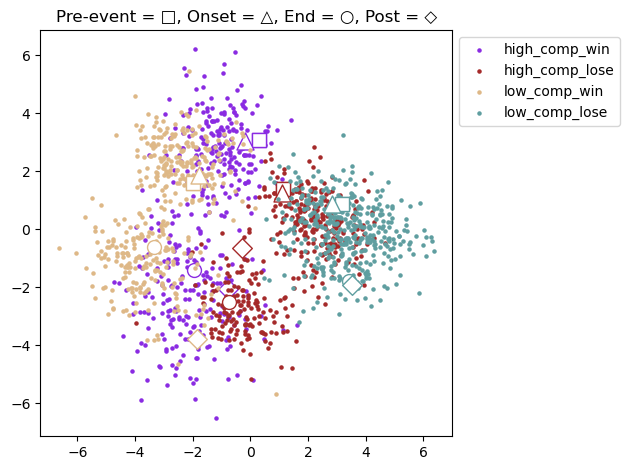

In [39]:

pca_result = pop.avg_trajectories_pca(rew_comp_spikes, event_length = 10, pre_window=5, post_window=5, min_neurons = 5,
                                      events = ['high_comp_win', 'high_comp_lose','low_comp_win', 'low_comp_lose'])

Excluding 20230613_105657_standard_comp_to_training_D2_subj_1-1_t1b2L_box1_merged.rec, it has no high_comp_lose events
Excluding 20230621_111240_standard_comp_to_omission_D5_subj_1-4_t3b3L_box1_merged.rec, it has no high_comp_win events
Excluding 20240317_172017_long_comp_subj_4-3_t5b5_merged.rec, it has no low_comp_lose events
Excluding 20240318_170933_long_comp_subj_4-3_t6b6_merged.rec, it has no low_comp_lose events
Excluding 20240318_143819_long_comp_subj_3-3_t6b6_merged.rec, it has no high_comp_win events
Excluding 20230620_114347_standard_comp_to_omission_D4_subj_1-1_t1b2L_box_2_merged.rec, it has no low_comp_lose events
Excluding 20240322_120625_alone_comp_subj_3-3_t6b6_merged.rec, it has no low_comp_win events
Excluding 20240322_160946_alone_comp_subj_4-3_t6b6_merged.rec, it has no low_comp_lose events
Excluding 20240323_122227_alone_comp_subj_5-2_t6b6_merged.rec, it has no high_comp_win events
Excluding 20240317_151922_long_comp_subj_3-3_t5b5_merged.rec, it has no low_comp_win

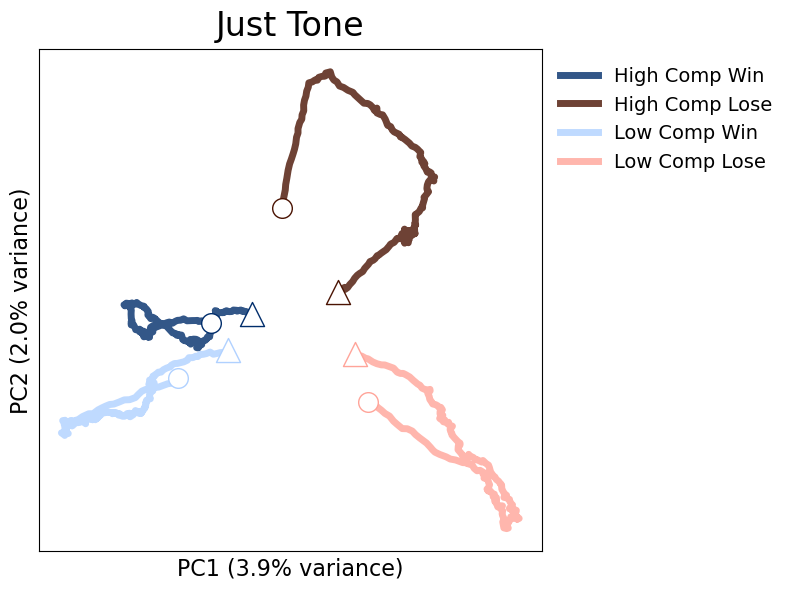

In [45]:
pca_result_justtone = pop.avg_trajectories_pca(rew_comp_spikes, event_length = 10, pre_window=0, post_window=0, min_neurons = 5,
                                      events = ['high_comp_win', 'high_comp_lose','low_comp_win', 'low_comp_lose'], plot=False)
plot_pca_results_2d(pca_result_justtone, title = 'Just Tone',
                    colors = ["#002D6B","#4A1302","#B0D1FF","#FFA499"],
                    legend_spot = (1,1),
                    custom_legend_labels=['High Comp Win', 'High Comp Lose', 'Low Comp Win', 'Low Comp Lose'],plot_range=(0,10),
                                      smooth_window = 50, )

In [34]:
# group_colors <- c(
#     "High Comp Win"  = "#002D6B",
#     "Low Comp Win"   = "#B0D1FF",
#     "High Comp Lose" = "#4A1302",
#     "Low Comp Lose"  = "#FFA499",
#     "Win"            = "#0045A6",
#     "Lose"           = "#9E3311",
#     "High Comp"      = "#171717",
#     "Low Comp"       = "#818689"
#   )

In [35]:
%pwd

'/blue/npadillacoreano/mcum/SocialMemEphys/diff_fam_social_memory_ephys'

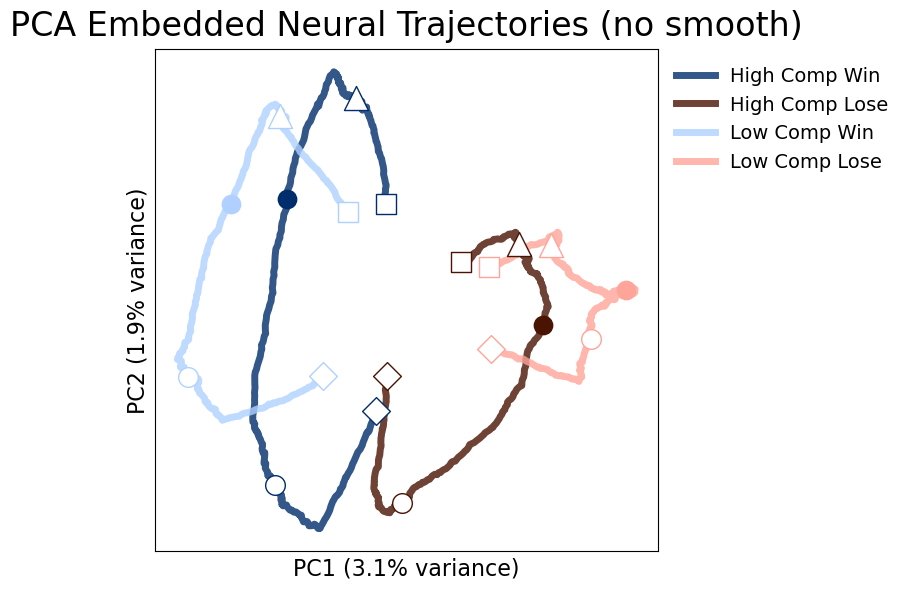

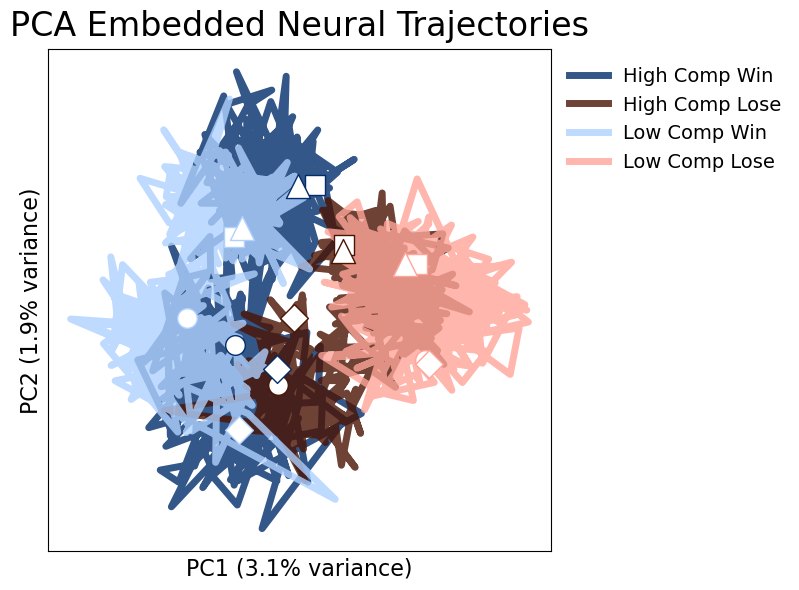

In [42]:
plot_pca_results_2d(pca_result, title = 'PCA Embedded Neural Trajectories (no smooth)',
                    colors = ["#002D6B","#4A1302","#B0D1FF","#FFA499"],
                    legend_spot = (1,1),
                    custom_legend_labels=['High Comp Win', 'High Comp Lose', 'Low Comp Win', 'Low Comp Lose'],plot_range=(-5,15),
                                      smooth_window = 100, mark_time = 5, save = True)
plot_pca_results_2d(pca_result, title = 'PCA Embedded Neural Trajectories',
                    colors = ["#002D6B","#4A1302","#B0D1FF","#FFA499"],
                    legend_spot = (1,1),
                    custom_legend_labels=['High Comp Win', 'High Comp Lose', 'Low Comp Win', 'Low Comp Lose'],plot_range=(-5,15),
                                      )                 

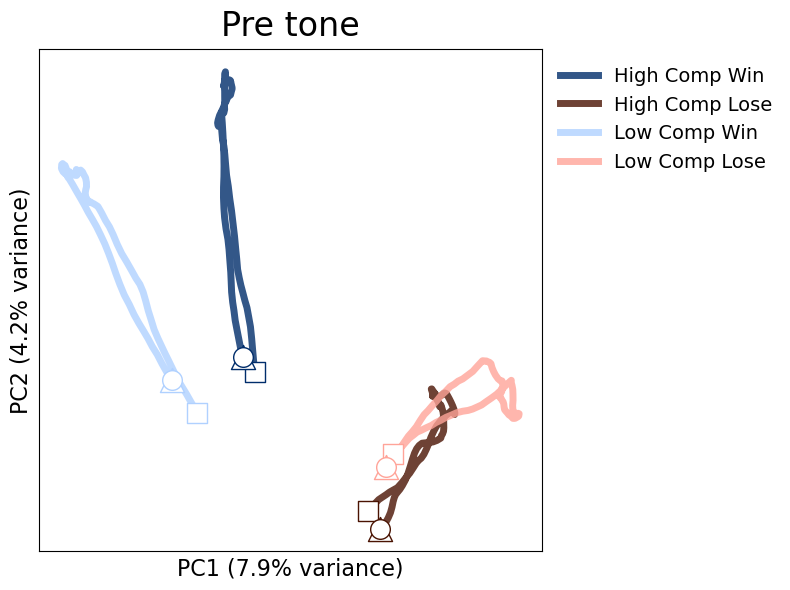

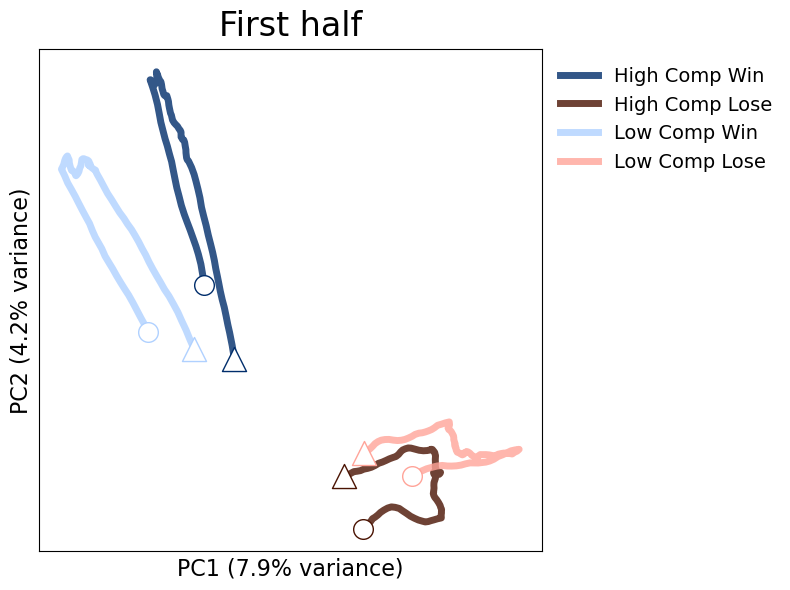

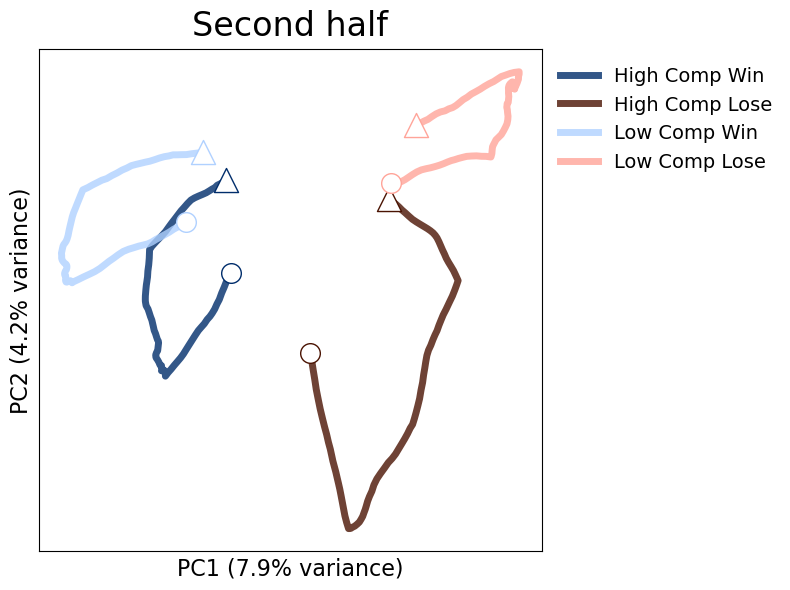

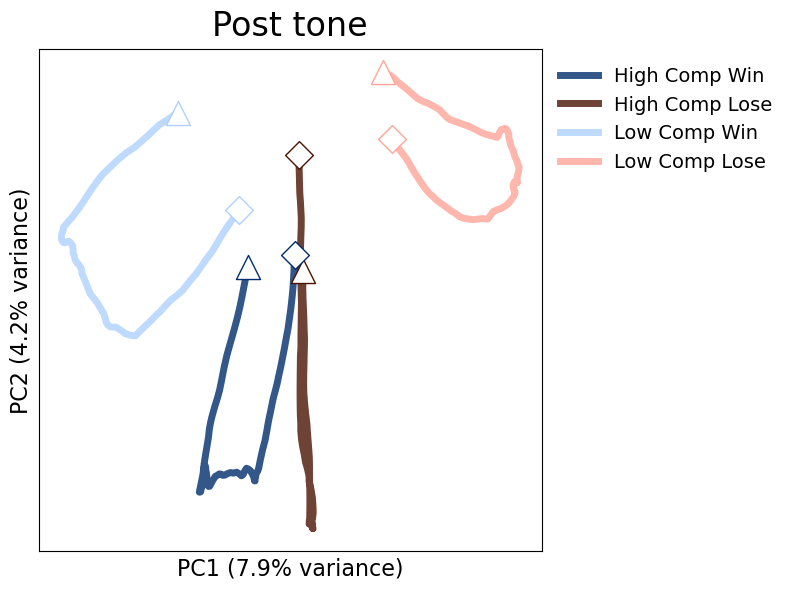

In [18]:
plot_pca_results_2d(pca_result, title = 'Pre tone',
                    colors = ["#002D6B","#4A1302","#B0D1FF","#FFA499"],
                    legend_spot = (1,1),
                    custom_legend_labels=['High Comp Win', 'High Comp Lose', 'Low Comp Win', 'Low Comp Lose'],plot_range=(-5,0),
                                      smooth_window = 50)
plot_pca_results_2d(pca_result, title = 'First half',
                    colors = ["#002D6B","#4A1302","#B0D1FF","#FFA499"],
                    legend_spot = (1,1),
                    custom_legend_labels=['High Comp Win', 'High Comp Lose', 'Low Comp Win', 'Low Comp Lose'],plot_range=(0,5),
                                      smooth_window = 50)
plot_pca_results_2d(pca_result, title = 'Second half',
                    colors = ["#002D6B","#4A1302","#B0D1FF","#FFA499"],
                    legend_spot = (1,1),
                    custom_legend_labels=['High Comp Win', 'High Comp Lose', 'Low Comp Win', 'Low Comp Lose'],plot_range=(5,10),
                                      smooth_window = 50)
plot_pca_results_2d(pca_result, title = 'Post tone',
                    colors = ["#002D6B","#4A1302","#B0D1FF","#FFA499"],
                    legend_spot = (1,1),
                    custom_legend_labels=['High Comp Win', 'High Comp Lose', 'Low Comp Win', 'Low Comp Lose'],plot_range=(10,15),
                                      smooth_window = 50)

Excluding 20230613_105657_standard_comp_to_training_D2_subj_1-1_t1b2L_box1_merged.rec, it has no high_comp_lose events
Excluding 20230621_111240_standard_comp_to_omission_D5_subj_1-4_t3b3L_box1_merged.rec, it has no high_comp_win events
Excluding 20240317_172017_long_comp_subj_4-3_t5b5_merged.rec, it has no low_comp_lose events
Excluding 20240318_170933_long_comp_subj_4-3_t6b6_merged.rec, it has no low_comp_lose events
Excluding 20240318_143819_long_comp_subj_3-3_t6b6_merged.rec, it has no high_comp_win events
Excluding 20230620_114347_standard_comp_to_omission_D4_subj_1-1_t1b2L_box_2_merged.rec, it has no low_comp_lose events
Excluding 20240322_120625_alone_comp_subj_3-3_t6b6_merged.rec, it has no low_comp_win events
Excluding 20240322_160946_alone_comp_subj_4-3_t6b6_merged.rec, it has no low_comp_lose events
Excluding 20240323_122227_alone_comp_subj_5-2_t6b6_merged.rec, it has no high_comp_win events
Excluding 20240317_151922_long_comp_subj_3-3_t5b5_merged.rec, it has no low_comp_win

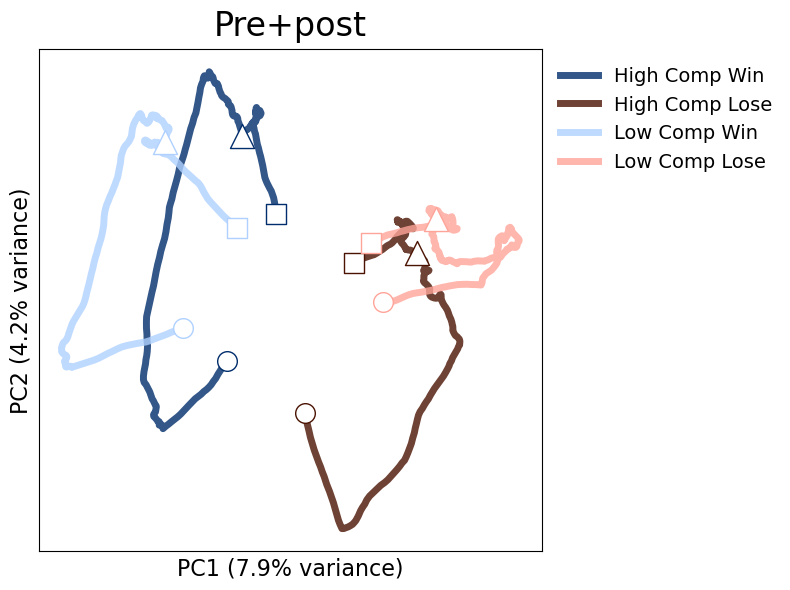

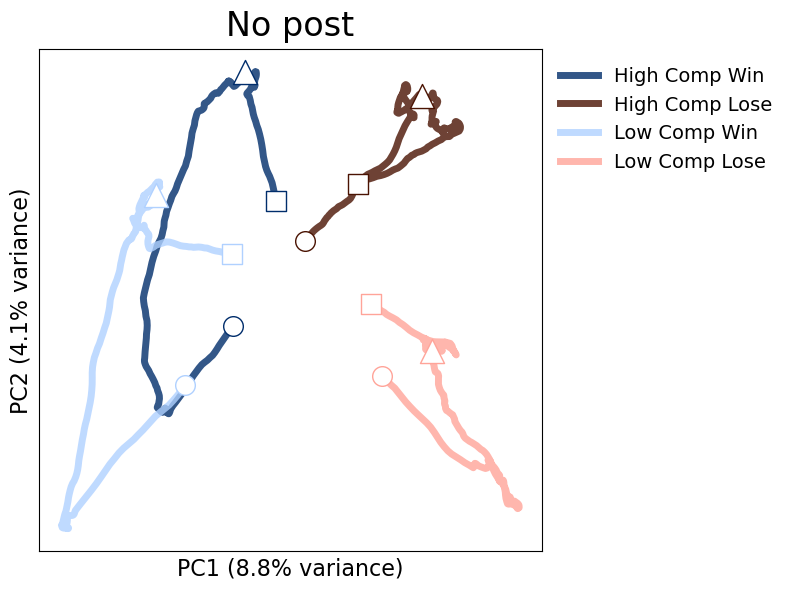

In [17]:

pca_result_nopost = pop.avg_trajectories_pca(rew_comp_spikes, event_length = 10, pre_window=5, min_neurons = 5,
                                      events = ['high_comp_win', 'high_comp_lose','low_comp_win', 'low_comp_lose'], plot = False)
plot_pca_results_2d(pca_result, title = 'Pre+post',
                    colors = ["#002D6B","#4A1302","#B0D1FF","#FFA499"],
                    legend_spot = (1,1),
                    custom_legend_labels=['High Comp Win', 'High Comp Lose', 'Low Comp Win', 'Low Comp Lose'],plot_range=(-5,10),
                                      smooth_window = 50)
plot_pca_results_2d(pca_result_nopost, title = 'No post',
                    colors = ["#002D6B","#4A1302","#B0D1FF","#FFA499"],
                    legend_spot = (1,1),
                    custom_legend_labels=['High Comp Win', 'High Comp Lose', 'Low Comp Win', 'Low Comp Lose'],plot_range=(-5,10),
                                      smooth_window = 50)

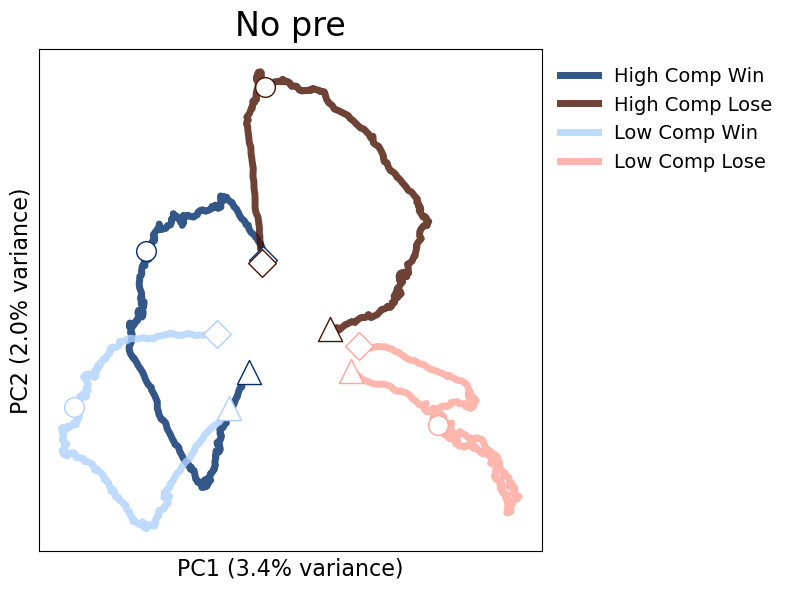

In [44]:
plot_pca_results_2d(pca_result_nopre, title = 'No pre',
                    colors = ["#002D6B","#4A1302","#B0D1FF","#FFA499"],
                    legend_spot = (1,1),
                    custom_legend_labels=['High Comp Win', 'High Comp Lose', 'Low Comp Win', 'Low Comp Lose'],plot_range=(0,15),
                                      smooth_window = 50)

Excluding 20230613_105657_standard_comp_to_training_D2_subj_1-1_t1b2L_box1_merged.rec, it has no high_comp_lose events
Excluding 20230621_111240_standard_comp_to_omission_D5_subj_1-4_t3b3L_box1_merged.rec, it has no high_comp_win events
Excluding 20240317_172017_long_comp_subj_4-3_t5b5_merged.rec, it has no low_comp_lose events
Excluding 20240318_170933_long_comp_subj_4-3_t6b6_merged.rec, it has no low_comp_lose events
Excluding 20240318_143819_long_comp_subj_3-3_t6b6_merged.rec, it has no high_comp_win events
Excluding 20230620_114347_standard_comp_to_omission_D4_subj_1-1_t1b2L_box_2_merged.rec, it has no low_comp_lose events
Excluding 20240322_120625_alone_comp_subj_3-3_t6b6_merged.rec, it has no low_comp_win events
Excluding 20240322_160946_alone_comp_subj_4-3_t6b6_merged.rec, it has no low_comp_lose events
Excluding 20240323_122227_alone_comp_subj_5-2_t6b6_merged.rec, it has no high_comp_win events
Excluding 20240317_151922_long_comp_subj_3-3_t5b5_merged.rec, it has no low_comp_win

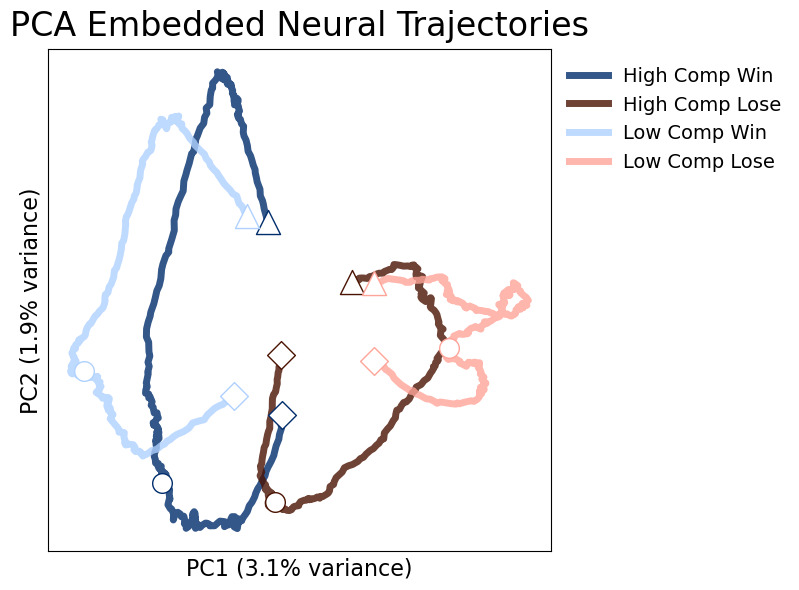

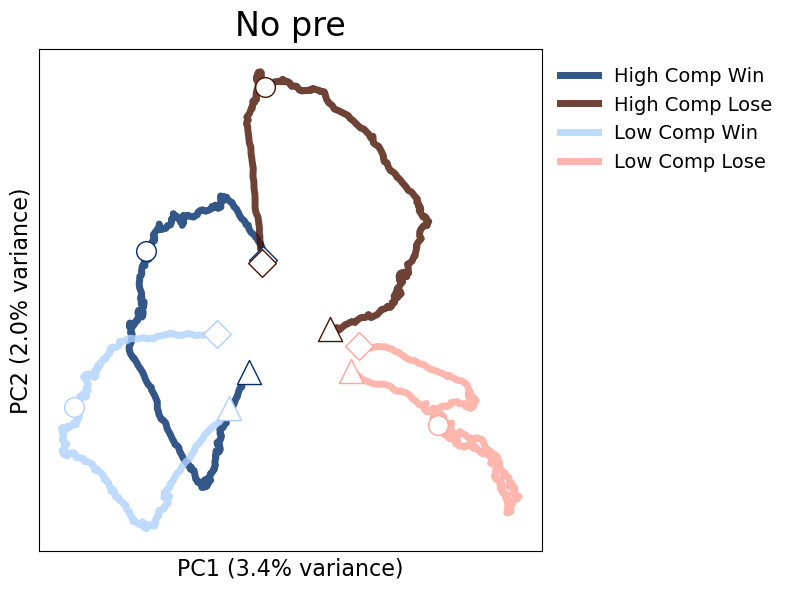

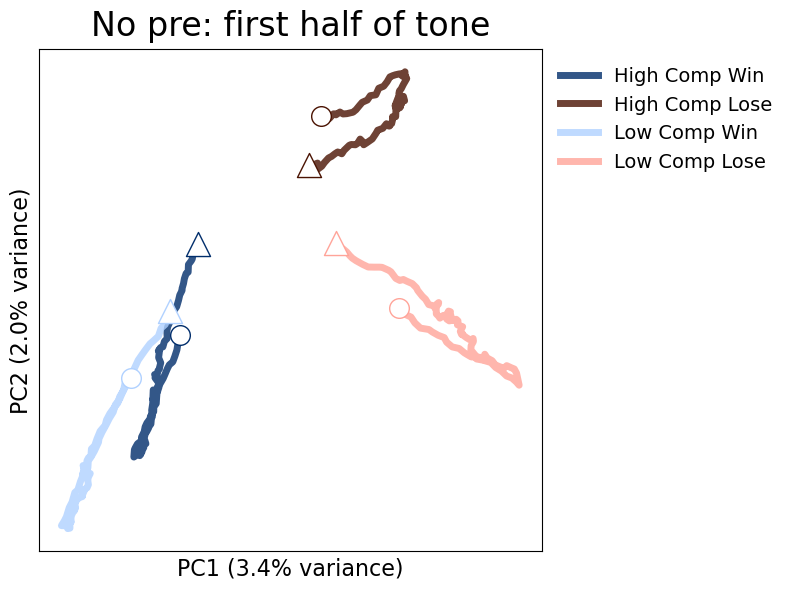

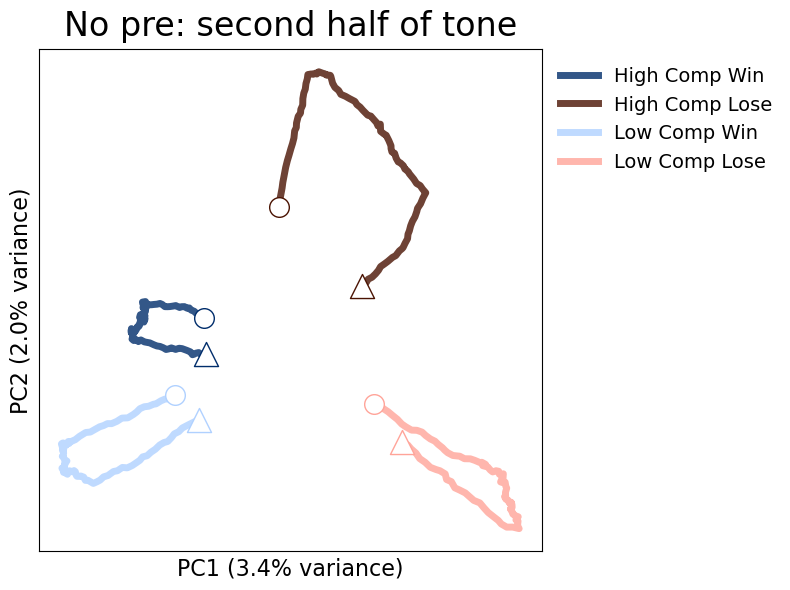

In [43]:

pca_result_nopre = pop.avg_trajectories_pca(rew_comp_spikes, event_length = 10, pre_window=0, post_window =5, min_neurons = 5,
                                      events = ['high_comp_win', 'high_comp_lose','low_comp_win', 'low_comp_lose'], plot = False)
plot_pca_results_2d(pca_result, title = 'PCA Embedded Neural Trajectories',
                    colors = ["#002D6B","#4A1302","#B0D1FF","#FFA499"],
                    legend_spot = (1,1),
                    custom_legend_labels=['High Comp Win', 'High Comp Lose', 'Low Comp Win', 'Low Comp Lose'],plot_range=(0,15),
                                      smooth_window = 50)

plot_pca_results_2d(pca_result_nopre, title = 'No pre: first half of tone',
                    colors = ["#002D6B","#4A1302","#B0D1FF","#FFA499"],
                    legend_spot = (1,1),
                    custom_legend_labels=['High Comp Win', 'High Comp Lose', 'Low Comp Win', 'Low Comp Lose'],plot_range=(0,5),
                                      smooth_window = 50)
plot_pca_results_2d(pca_result_nopre, title = 'No pre: second half of tone',
                    colors = ["#002D6B","#4A1302","#B0D1FF","#FFA499"],
                    legend_spot = (1,1),
                    custom_legend_labels=['High Comp Win', 'High Comp Lose', 'Low Comp Win', 'Low Comp Lose'],plot_range=(5,10),
                                      smooth_window = 50)

In [23]:
from ipywidgets import interact                                                                                                                                                   
import ipywidgets as widgets                                                                                                                                                      

def interactive_pca_3d(pca_result, title, colors, **kwargs):                                                                                                                      
    @interact(
      azim=widgets.IntSlider(min=0, max=360, step=5, value=0, description='Azimuth'),                                                                                           
      elev=widgets.IntSlider(min=-90, max=90, step=5, value=30, description='Elevation')                                                                                      
  )                                                                                                                                                                             
    def _plot(azim, elev):
        plt.close('all')                                                                                                                                                          
        plot_pca_results_3d(pca_result, title, colors, azim=azim, elev=elev, save=False, **kwargs)   
interactive_pca_3d(pca_result, title = 'PCA Embedded Neural Trajectories',
                    colors = ["#002D6B","#4A1302","#B0D1FF","#FFA499"],
                    #legend_spot = (1,1),
                    #custom_legend_labels=['High Comp Win', 'High Comp Lose', 'Low Comp Win', 'Low Comp Lose'],
                    plot_range=(-5,15),
                    smooth_window = 50)

interactive(children=(IntSlider(value=0, description='Azimuth', max=360, step=5), IntSlider(value=30, descript…

In [ ]:
rew_comp_spikes.analyze(timebin = 50, ignore_freq = 0.5, smoothing_window = 250)
ccgp = decoders.trial_decoder_cross_generalization_2x2(rew_comp_spikes, 
                                                events = [['high_comp_win', 'high_comp_lose'], ['low_comp_win', 'low_comp_lose']],
                                                event_length =15,
                                                       pre_window = 5,
                                                 min_neurons = 5,
                                                num_fold = 5,     
                                                classifier_type = 'linear') 
import pickle
with open("rce_test/ccgp_prewindow_smoothed.pkl", "wb") as file:
    # 2. Dump the object into the file
    pickle.dump(ccgp, file)

Your event dictionary keys are different across recordings.
Please double check them:
20240320_142408_alone_comp_subj_3-3_t5b5_merged.rec keys: dict_keys(['alone_rewarded', 'alone_rewarded_baseline', 'high_comp', 'high_comp_lose', 'high_comp_lose_baseline', 'high_comp_tie', 'high_comp_win', 'high_comp_win_baseline', 'lose', 'low_comp', 'low_comp_lose', 'low_comp_lose_baseline', 'low_comp_win', 'low_comp_win_baseline', 'overall_pretone', 'win'])
20230613_105657_standard_comp_to_training_D2_subj_1-1_t1b2L_box1_merged.rec keys: dict_keys(['alone_rewarded', 'alone_rewarded_baseline', 'high_comp', 'high_comp_lose', 'high_comp_lose_baseline', 'high_comp_win', 'high_comp_win_baseline', 'lose', 'low_comp', 'low_comp_lose', 'low_comp_lose_baseline', 'low_comp_win', 'low_comp_win_baseline', 'win'])
20230621_111240_standard_comp_to_omission_D5_subj_1-4_t3b3L_box1_merged.rec keys: dict_keys(['alone_rewarded', 'alone_rewarded_baseline', 'high_comp', 'high_comp_lose', 'high_comp_lose_baseline', 'hig

2x2 cross-gen pairs:   0%|          | 0/6 [00:00<?, ?it/s]

folds (high_comp_win/high_comp_lose):   0%|          | 0/5 [00:00<?, ?it/s]

shuffles (high_comp_win/high_comp_lose):   0%|          | 0/25 [00:00<?, ?it/s]

In [6]:
import pickle

# Open the file in read-binary mode
with open('rce_test/ccgp_prewindow_smoothed.pkl', 'rb') as file:
    ccgp = pickle.load(file)



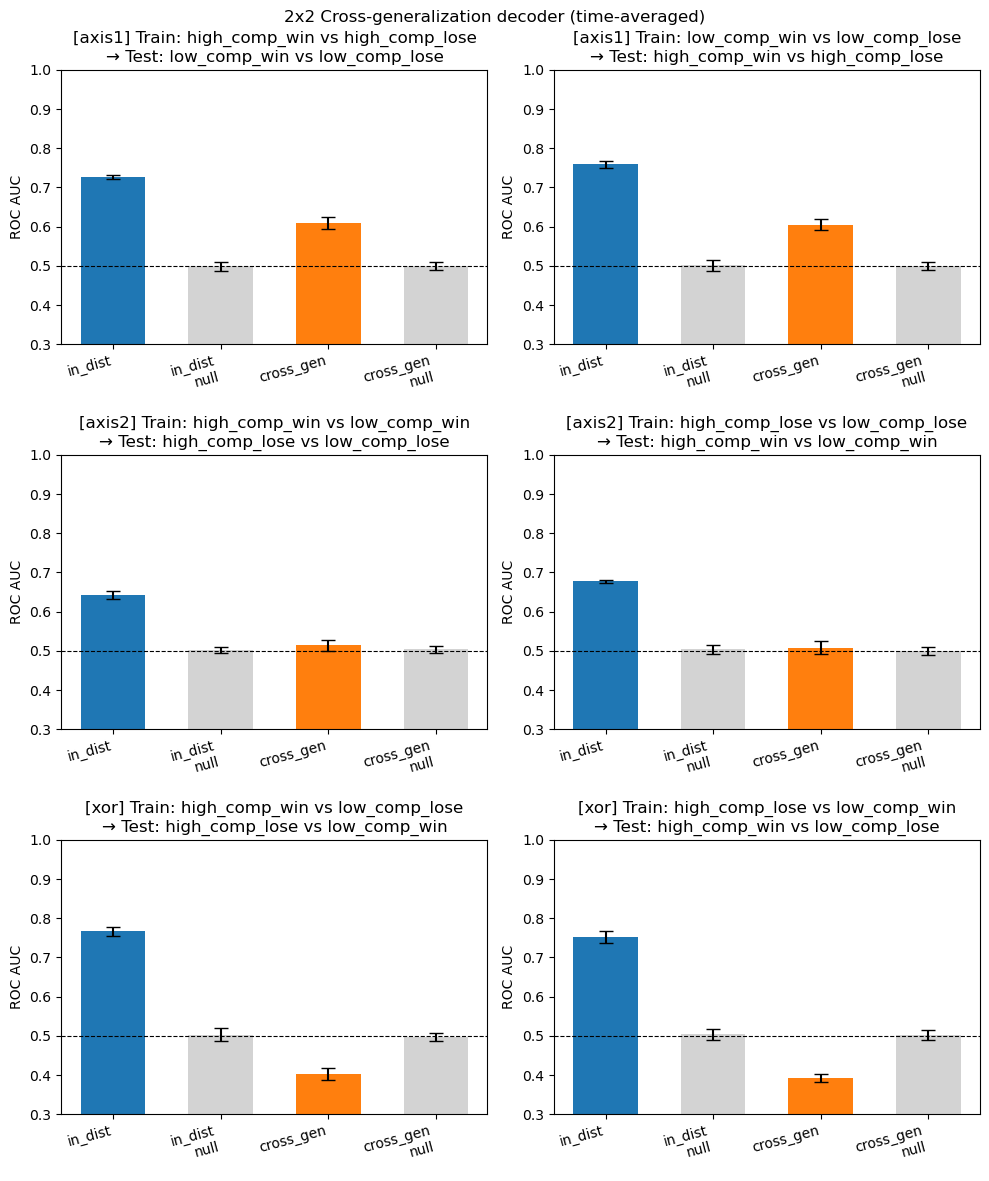

In [7]:
ccgp.plot_average(start=0, stop = 10)

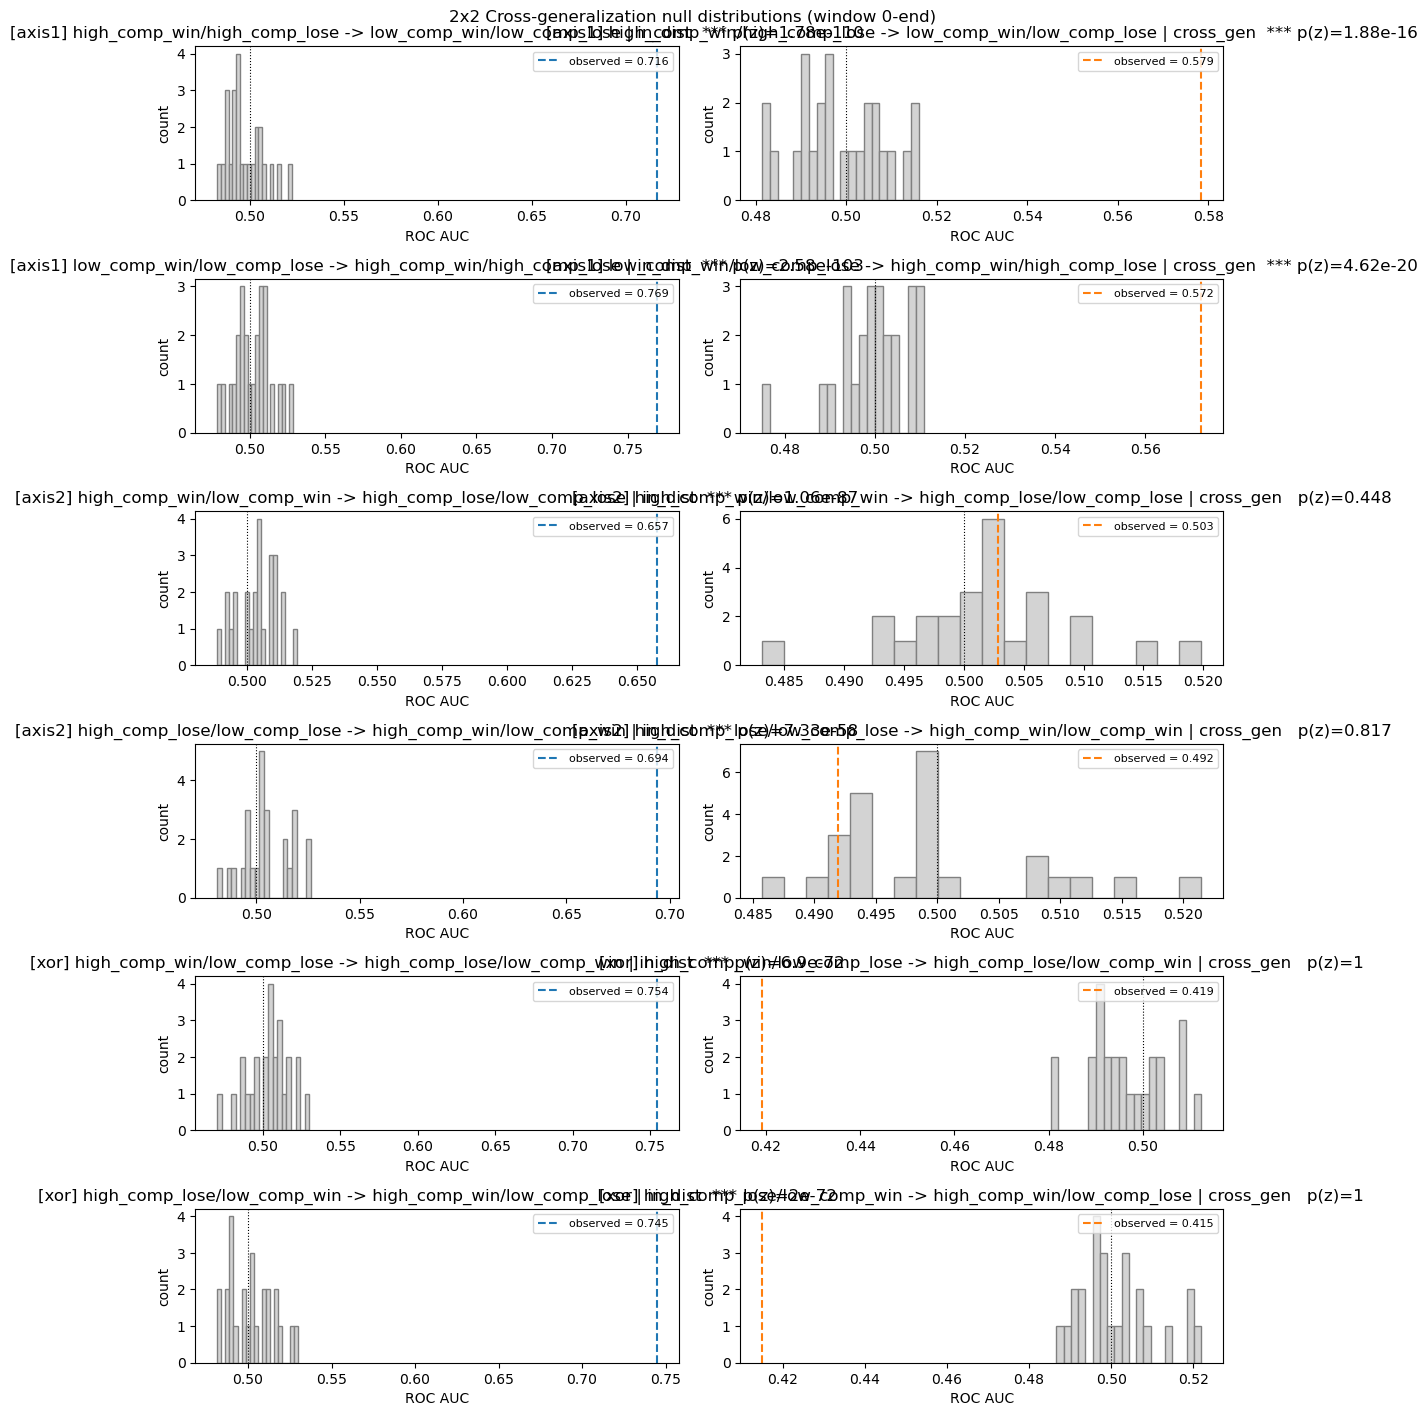

In [8]:
ccgp.plot_null_distribution()

In [9]:
from scipy.stats import sem, ttest_ind                                                                                                                                                                                                                                                                                  
                                                                                                                                                                                                                                                                                                                          
def plot_average(ccgp_object, colors, start=0, stop=None, collapse=False,                                                                                                                                                                                                                                               
                titles=None, xtick_labels=None, suptitle=None):                                                                                                                                                                                                                                                                       
                                                                                                                                                                                                                                                                                                                    
    def sig_stars(p):AA
        if p < 0.001: return "***"
        elif p < 0.01:  return "**"
        elif p < 0.05:  return "*"
        else:           return "ns"

    def annotate_bars(ax, x_pos, means, errors, pvals):
        for xi, mean, err, p in zip(x_pos, means, errors, pvals):
            if p is not None:
                ax.text(xi, mean + err + 0.02, sig_stars(p),
                        ha="center", va="bottom", fontsize=10)

    def fold_array(nmr, start, stop, ccgp_object):
        T = nmr.roc_auc.shape[0]
        x = np.linspace(-ccgp_object.pre_window,
                        ccgp_object.event_length + ccgp_object.post_window, T)
        start_idx = np.searchsorted(x, start)
        stop_idx  = T if stop is None else np.searchsorted(x, stop)
        return np.nanmean(nmr.roc_auc[start_idx:stop_idx], axis=0)

    def mean_err(arr):
        clean = arr[~np.isnan(arr)]
        return np.nanmean(clean), sem(clean, nan_policy="omit")

    def vs_shuffle_p(arr, shuf_arr):
        a = arr[~np.isnan(arr)]
        b = shuf_arr[~np.isnan(shuf_arr)]
        _, p = ttest_ind(a, b, alternative="greater")
        return p

    train_keys  = list(ccgp_object.roc_auc_scores.keys())
    axis_groups = [train_keys[0:2], train_keys[2:4]]
    if len(train_keys) >= 6:
        axis_groups.append(train_keys[4:6])
    n_groups = len(axis_groups)

    bar_width = 0.4

    # ------------------------------------------------------------------ #
    #  COLLAPSE MODE                                                       #
    # ------------------------------------------------------------------ #
    if collapse:
        fig, axes = plt.subplots(1, n_groups, figsize=(3 * n_groups, 4), sharey=True)
        if n_groups == 1:
            axes = [axes]

        for ax_idx, (ax, group_keys, axis_colors) in enumerate(
                zip(axes, axis_groups, colors)):

            in_dist_folds   = []
            cross_gen_folds = []
            shuffle_folds   = []

            for train_key in group_keys:
                results = ccgp_object.roc_auc_scores[train_key]
                for result_type, nmr in results.items():
                    arr = fold_array(nmr, start, stop, ccgp_object)
                    if result_type == "in_dist":
                        in_dist_folds.append(arr)
                    elif result_type == "cross_gen":
                        cross_gen_folds.append(arr)
                    elif result_type == "shuffle":
                        shuffle_folds.append(arr)

            def pool(fold_list):
                return np.concatenate(fold_list) if fold_list else np.array([np.nan])

            in_arr    = pool(in_dist_folds)
            cross_arr = pool(cross_gen_folds)
            shuf_arr  = pool(shuffle_folds)

            in_mean,    in_err    = mean_err(in_arr)
            cross_mean, cross_err = mean_err(cross_arr)
            shuf_mean,  shuf_err  = mean_err(shuf_arr)

            means      = [in_mean,        cross_mean,    shuf_mean]
            errors     = [in_err,         cross_err,     shuf_err]
            pvals      = [vs_shuffle_p(in_arr, shuf_arr),
                        vs_shuffle_p(cross_arr, shuf_arr),
                        None]  # shuffle bar needs no annotation
            bar_colors = [axis_colors[0], axis_colors[1], "lightgray"]

            xlabels = xtick_labels[ax_idx] if xtick_labels is not None else ["in-dist", "cross-gen", "shuffle"]

            x_pos = np.arange(3)
            ax.bar(x_pos, means, bar_width, yerr=errors, capsize=5,
                    color=bar_colors,
                    error_kw={"elinewidth": 1.5, "capthick": 1.5})
            annotate_bars(ax, x_pos, means, errors, pvals)
            ax.set_xticks(x_pos)
            ax.set_xticklabels(xlabels, rotation=0, ha="center")
            ax.axhline(0.5, color="k", linestyle="--", linewidth=0.8)
            ax.set_ylim(0.3, 1.0)
            ax.set_ylabel("ROC AUC")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            title = titles[ax_idx] if titles is not None else ("XOR" if ax_idx == 2 else f"Axis {ax_idx + 1}")
            ax.set_title(title, fontsize=13)

    # ------------------------------------------------------------------ #
    #  FULL MODE                                                           #
    # ------------------------------------------------------------------ #
    else:
        fig, axes_grid = plt.subplots(n_groups, 2, figsize=(10, 4 * n_groups), sharey=True)
        if n_groups == 1:
            axes_grid = axes_grid[np.newaxis, :]

        for axis_idx, (group_keys, axis_colors) in enumerate(
                zip(axis_groups, colors)):

            for subplot_idx, train_key in enumerate(group_keys):
                ax = axes_grid[axis_idx, subplot_idx]
                results = ccgp_object.roc_auc_scores[train_key]
                result_items = list(results.items())

                # get shuffle array first so we can test against it
                shuf_arr = next(
                    (fold_array(nmr, start, stop, ccgp_object)
                    for rt, nmr in result_items if rt == "shuffle"),
                    None
                )

                means, errors, pvals, bar_colors = [], [], [], []

                for j, (result_type, nmr) in enumerate(result_items):
                    arr = fold_array(nmr, start, stop, ccgp_object)
                    mean, err = mean_err(arr)
                    means.append(mean)
                    errors.append(err)

                    if result_type == "shuffle" or shuf_arr is None:
                        pvals.append(None)
                        bar_colors.append("lightgray")
                    else:
                        pvals.append(vs_shuffle_p(arr, shuf_arr))
                        bar_colors.append(axis_colors[0] if j == 0 else axis_colors[1])

                if xtick_labels is not None:
                    xlabels = list(xtick_labels[axis_idx][subplot_idx])
                    while len(xlabels) < len(result_items):
                        xlabels.append("shuffle")
                else:
                    xlabels = [rt for rt, _ in result_items]

                x_pos = np.arange(len(result_items))
                ax.bar(x_pos, means, bar_width, yerr=errors, capsize=5,
                        color=bar_colors,
                        error_kw={"elinewidth": 1.5, "capthick": 1.5})
                annotate_bars(ax, x_pos, means, errors, pvals)
                ax.set_xticks(x_pos)
                ax.set_xticklabels(xlabels, rotation=15, ha="center")
                ax.axhline(0.5, color="k", linestyle="--", linewidth=0.8)
                ax.set_ylim(0.3, 1.0)
                ax.set_ylabel("ROC AUC")
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)

                if titles is not None:
                    title = titles[axis_idx][subplot_idx]
                else:
                    title = "XOR" if axis_idx == 2 else f"Axis {axis_idx+1}, subplot {subplot_idx+1}"
                ax.set_title(title, fontsize=12)
    if suptitle is None:
        suptitle = "2x2 Cross-generalization decoder (time-averaged)"
    plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

plot_average(ccgp, 
             colors = [['#AD2105',"#0521AD"],
                       ["#b0b0b0","#2c2c2c"],
                       ["#434343","#4a4a4a"]],
                       start = 0 , stop =10, collapse = True,
             titles = ['Win vs Lose', 
                       'High comp vs low comp', 
                       'XOR Control'],
             xtick_labels = [['Linear','CCGP', 'shuffle'],
                             ['Linear','CCGP', 'shuffle'],
                             ['Linear','CCGP', 'shuffle']],
             suptitle = 'All 10 seconds')


IndentationError: unexpected indent (3001020996.py, line 7)

In [ ]:
plot_average(ccgp, 
             colors = [['#AD2105',"#0521AD"],
                       ["#b0b0b0","#2c2c2c"],
                       ["#434343","#4a4a4a"]],
                       start = 0 , stop =5, collapse = True,
             titles = ['Win vs Lose', 
                       'High comp vs low comp', 
                       'XOR Control'],
             xtick_labels = [['Linear','CCGP', 'shuffle'],
                             ['Linear','CCGP', 'shuffle'],
                             ['Linear','CCGP', 'shuffle']],
             suptitle = 'Seconds 0-5')

In [ ]:
plot_average(ccgp, 
             colors = [['#AD2105',"#0521AD"],
                       ["#b0b0b0","#2c2c2c"],
                       ["#434343","#4a4a4a"]],
                       start = 5 , stop =10, collapse = True,
             titles = ['Win vs Lose', 
                       'High comp vs low comp', 
                       'XOR Control'],
             xtick_labels = [['Linear','CCGP', 'shuffle'],
                             ['Linear','CCGP', 'shuffle'],
                             ['Linear','CCGP', 'shuffle']],
             suptitle = 'Seconds 5-10')

In [ ]:
plot_average(ccgp, 
             colors = [['#AD2105',"#0521AD"],
                       ["#b0b0b0","#2c2c2c"],
                       ["#434343","#4a4a4a"]],
                       start = 10 , stop =15, collapse = True,
             titles = ['Win vs Lose', 
                       'High comp vs low comp', 
                       'XOR Control'],
             xtick_labels = [['Linear','CCGP', 'shuffle'],
                             ['Linear','CCGP', 'shuffle'],
                             ['Linear','CCGP', 'shuffle']],
             suptitle = 'Post tone: seconds 10-15')

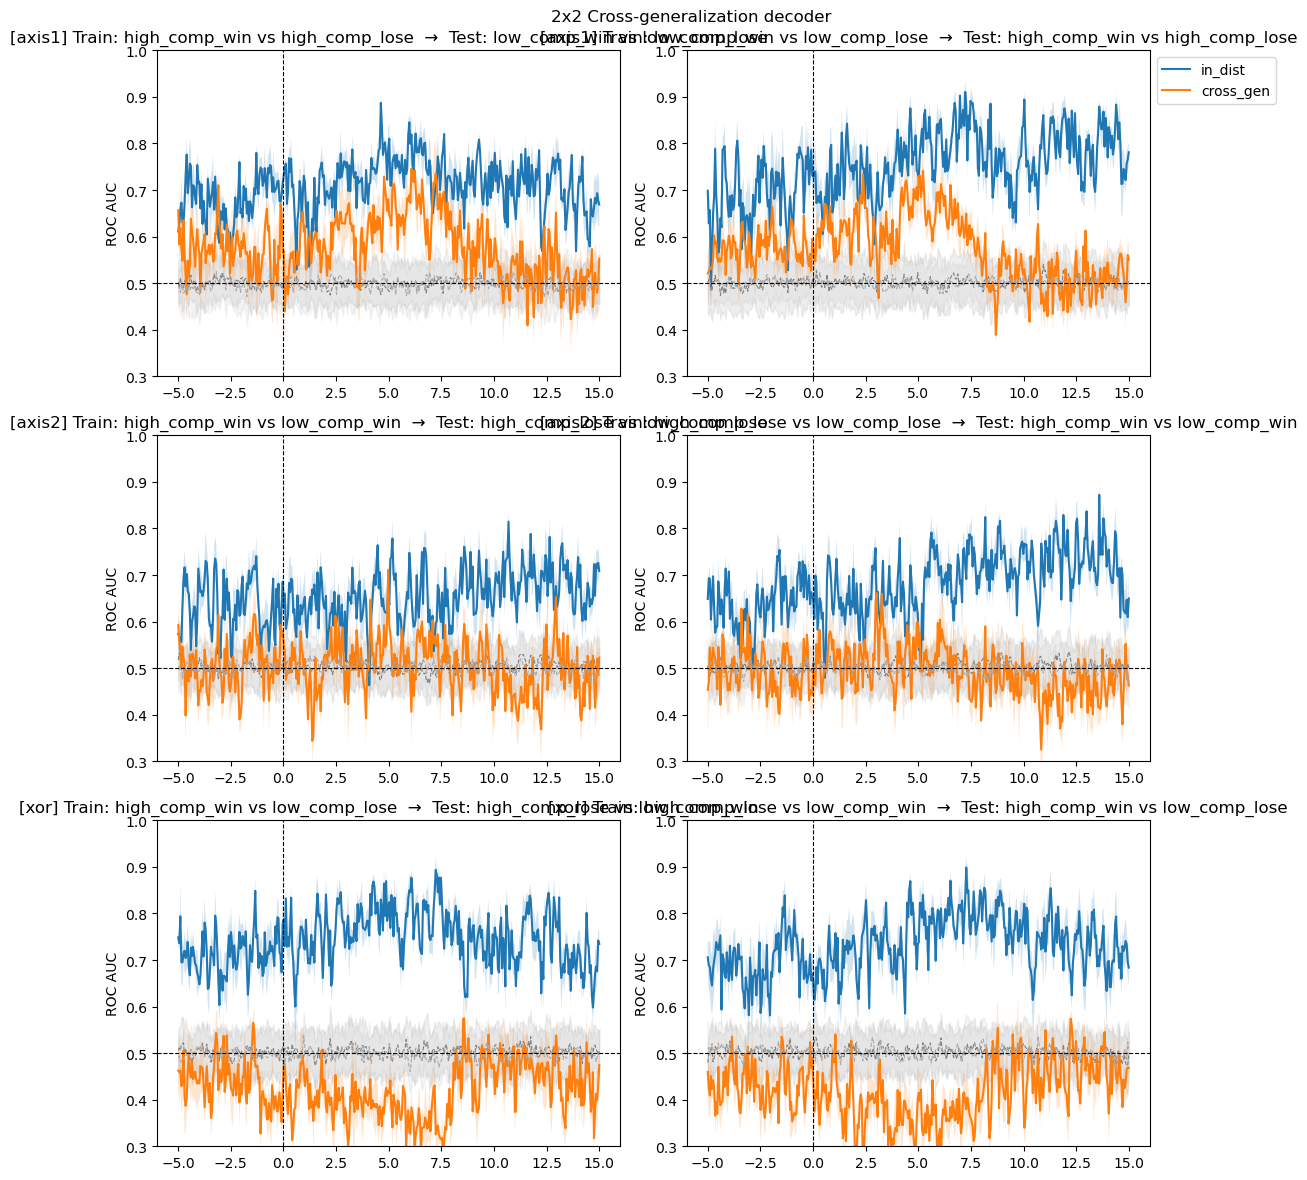

In [10]:
ccgp.plot_across_time()

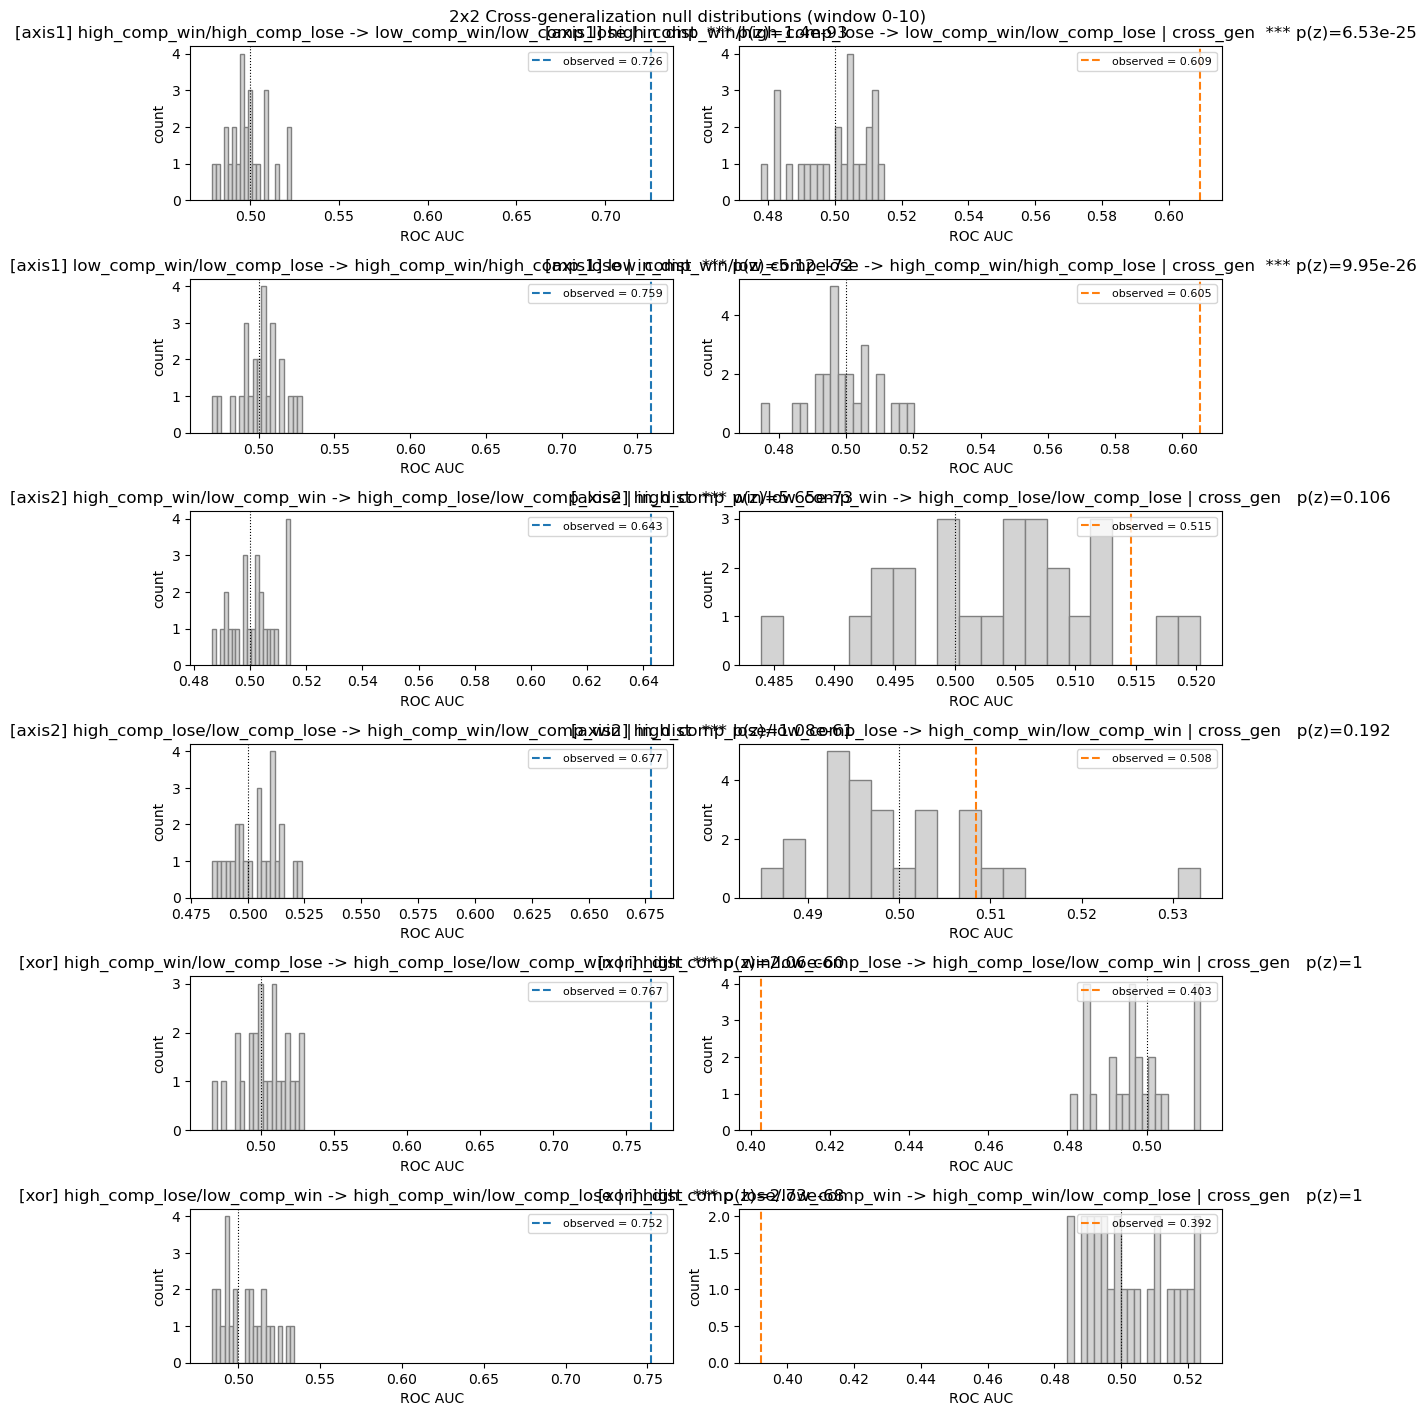

In [11]:
ccgp.plot_null_distribution(start = 0, stop = 10)

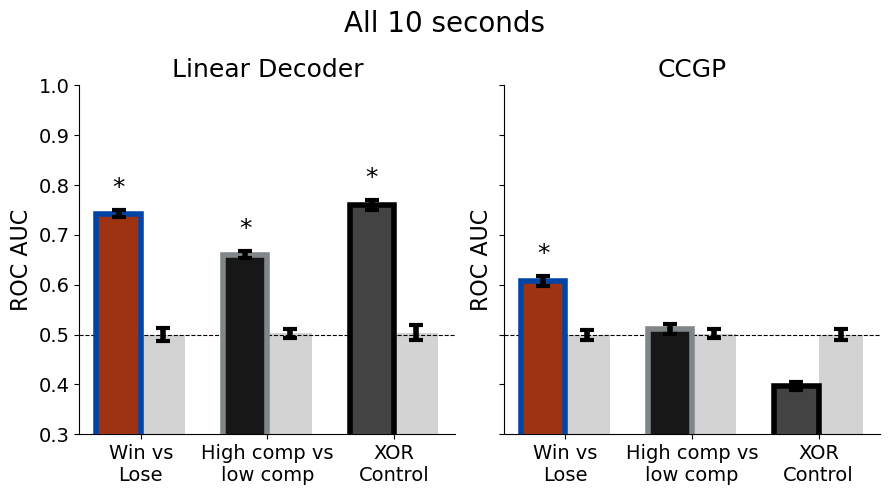

In [12]:
from scipy.stats import sem                                                   
                                                                                
def plot_average(ccgp_object, colors, edge_colors, start=0, stop=None,                       
               titles=None, xtick_labels=None, suptitle=None, ):
    """                                                                         
    colors       : [axis1_color, axis2_color, xor_color, shuffle_color]
    titles       : [linear_panel_title, ccgp_panel_title]                       
    xtick_labels : [axis1_label, axis2_label, xor_label]                      
    """                                                                         

    def sig_stars(p):                                                           
      if p < 0.001: return "***"                                            
      if p < 0.01:  return "**"                                               
      if p < 0.05:  return "*"                                              
      return ""                                                               

    def time_slice(arr_2d):                                                     
      T = arr_2d.shape[0]                                                   
      x = np.linspace(-ccgp_object.pre_window,                                
                      ccgp_object.event_length + ccgp_object.post_window, T)  
      i0 = int(np.searchsorted(x, start))                                     
      i1 = T if stop is None else int(np.searchsorted(x, stop))               
      return np.nanmean(arr_2d[i0:i1], axis=0)                                

    def count_pval(obs_scalar, null_vec):                                       
      n   = np.sum(~np.isnan(null_vec))                                       
      cnt = np.nansum(null_vec >= obs_scalar)                                 
      return (cnt + 1.0) / (n + 1.0)                                          

    train_keys  = list(ccgp_object.roc_auc_scores.keys())                       
    axis_groups = [train_keys[0:2], train_keys[2:4]]                            
    if len(train_keys) >= 6:                                                    
      axis_groups.append(train_keys[4:6])                                   
    n_groups = len(axis_groups)                                                 

    dec_colors    = colors[:n_groups]                                         
    shuffle_color = colors[3]                                                   

    if xtick_labels is None:                                                  
      xtick_labels = [f"Axis {i + 1}" for i in range(n_groups - 1)] + ["XOR"] 
    if titles is None:                                                          
      titles = ["Linear Decoder", "CCGP"]                                   
    if suptitle is None:                                                        
      suptitle = "2x2 Cross-generalization decoder (time-averaged)"

    fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=True)                
    bar_width = 0.35                                                            
    group_x   = np.arange(n_groups)                                             

    for ax, rt, title in zip(axes, ["in_dist", "cross_gen"], titles):           
      obs_means, obs_errs   = [], []                                          
      shuf_means, shuf_errs = [], []                                          
      pvals = []                                                              

      for group_keys in axis_groups:                                          
          obs_folds = np.concatenate([
              time_slice(ccgp_object.roc_auc_scores[tk][rt].roc_auc)          
              for tk in group_keys                                            
          ])                                                                  
          obs_folds = obs_folds[~np.isnan(obs_folds)]                         

          null_vec = np.concatenate([                                       
              time_slice(ccgp_object.shuffles[tk][rt])                        
              for tk in group_keys    
          ])                                                                  
          null_vec = null_vec[~np.isnan(null_vec)]

          obs_mean = float(np.nanmean(obs_folds))                             
          obs_means.append(obs_mean)                                        
          obs_errs.append(float(sem(obs_folds, nan_policy="omit")))           
          shuf_means.append(float(np.nanmean(null_vec)))                      
          shuf_errs.append(float(np.nanstd(null_vec, ddof=1)))              
          pvals.append(count_pval(obs_mean, null_vec))                        

      ax.bar(group_x - bar_width / 2, obs_means, bar_width,                 
             yerr=obs_errs, capsize=5, color=dec_colors, 
             edgecolor = edge_colors, zorder = 3, linewidth = 4,                      
             error_kw={"elinewidth": 4, "capthick": 3})                   
      ax.bar(group_x + bar_width / 2, shuf_means, bar_width,                
             yerr=shuf_errs, capsize=5, color=shuffle_color, zorder =2,                 
             error_kw={"elinewidth": 4, "capthick": 3})

      for xi, m, e, p in zip(group_x - bar_width / 2, obs_means, obs_errs,    
    pvals):                                                                       
          stars = sig_stars(p)                                                
          if stars:                   
              ax.text(xi, m + e + 0.02, stars, ha="center", va="bottom",    
    fontsize=18)                                                                    

      ax.set_xticks(group_x)                                                  
      ax.set_xticklabels(xtick_labels[:n_groups], rotation=0, ha="center")
      ax.axhline(0.5, color="k", linestyle="--", linewidth=0.8)               
      ax.set_ylim(0.3, 1.0)
      ax.set_ylabel("ROC AUC", fontsize = 16)  
      ax.tick_params(labelsize=14)
      ax.set_title(title, fontsize=18)
      ax.spines["top"].set_visible(False)                                     
      ax.spines["right"].set_visible(False)
                                                                         

    plt.suptitle(suptitle, fontsize = 20)
    plt.tight_layout()                                                          
    plt.show()
    return fig



all_10_seconds = plot_average(ccgp,                                                              
           colors=['#9E3311', '#171717', '#434343', 'lightgray'],
             edge_colors = ['#0045A6', '#818689', 'black'],
           start=0, stop=10,                                                
           titles=['Linear Decoder', 'CCGP'],                                 
           xtick_labels=['Win vs\nLose', 'High comp vs\nlow comp', 'XOR\nControl'], 
             
           suptitle='All 10 seconds') 
all_10_seconds.savefig("rce_test/fulltone.pdf", bbox_inches='tight')

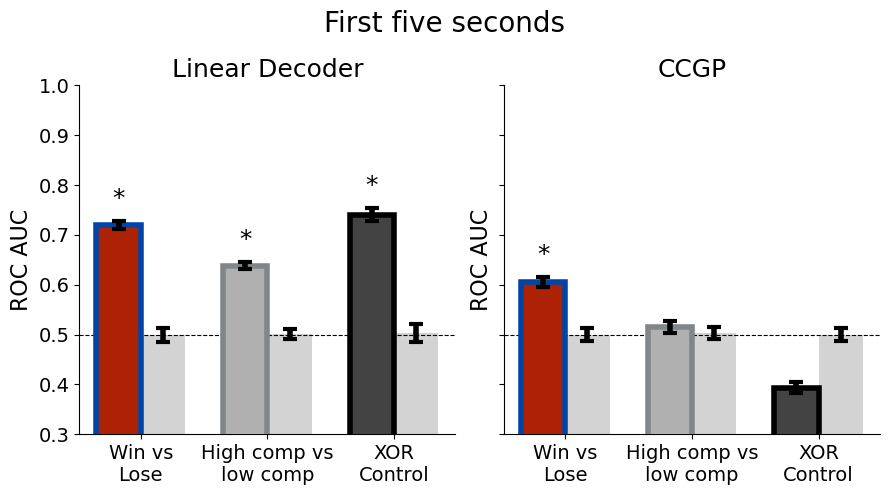

In [13]:
plot_05 = plot_average(ccgp,                                                              
           colors=['#AD2105', '#b0b0b0', '#434343', 'lightgray'],
             edge_colors = ['#0045A6', '#818689', 'black'],
           start=0, stop=5,                                                
           titles=['Linear Decoder', 'CCGP'],                                 
           xtick_labels=['Win vs\nLose', 'High comp vs\nlow comp', 'XOR\nControl'],                                                                      
           suptitle='First five seconds') 
plot_05.savefig("rce_test/firstfive.pdf", bbox_inches='tight')

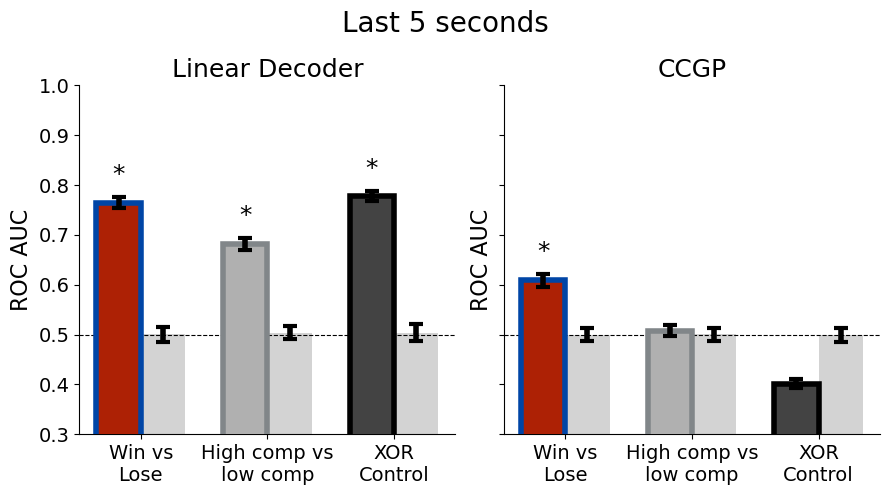

In [14]:
plot_510 = plot_average(ccgp,                                                              
           colors=['#AD2105', '#b0b0b0', '#434343', 'lightgray'],
             edge_colors = ['#0045A6', '#818689', 'black'],
           start=5, stop=10,                                                
           titles=['Linear Decoder', 'CCGP'],                                 
           xtick_labels=['Win vs\nLose', 'High comp vs\nlow comp', 'XOR\nControl'],                                                                      
           suptitle='Last 5 seconds') 
plot_510.savefig("rce_test/lastfive.pdf", bbox_inches = 'tight')

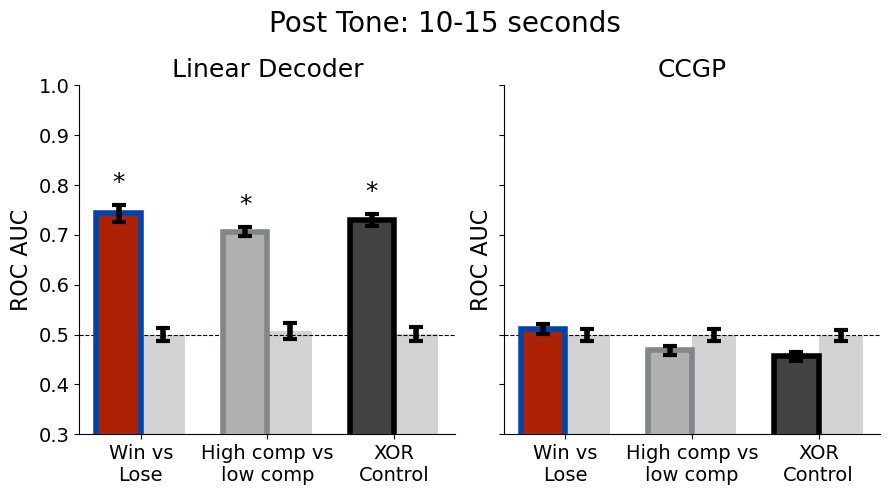

In [15]:
plot_post = plot_average(ccgp,                                                              
           colors=['#AD2105', '#b0b0b0', '#434343', 'lightgray'],
             edge_colors = ['#0045A6', '#818689', 'black'],
           start=10, stop=15,                                                
           titles=['Linear Decoder', 'CCGP'],                                 
           xtick_labels=['Win vs\nLose', 'High comp vs\nlow comp', 'XOR\nControl'],                                                                       
           suptitle='Post Tone: 10-15 seconds') 
plot_post.savefig('rce_test/posttone.pdf', bbox_inches = 'tight')

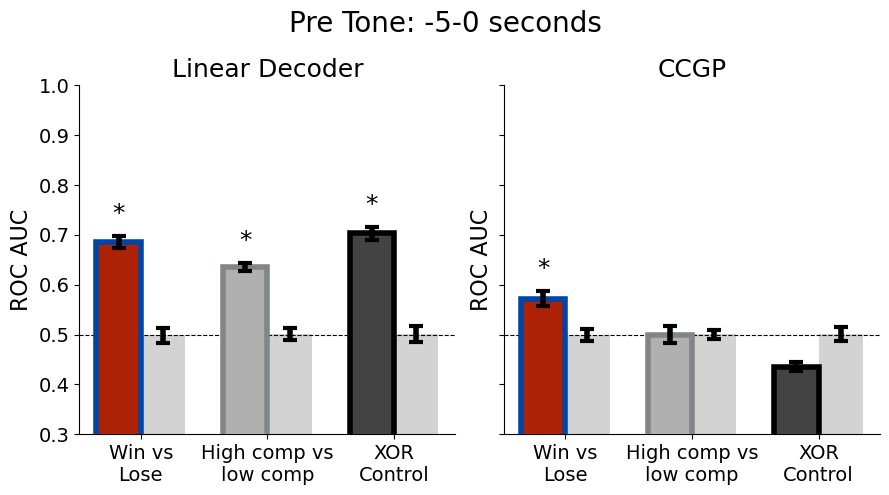

In [17]:
plot_pre = plot_average(ccgp,                                                              
           colors=['#AD2105', '#b0b0b0', '#434343', 'lightgray'],
             edge_colors = ['#0045A6', '#818689', 'black'],
           start=-5, stop=0,                                                
           titles=['Linear Decoder', 'CCGP'],                                 
           xtick_labels=['Win vs\nLose', 'High comp vs\nlow comp', 'XOR\nControl'],                                                                      
           suptitle='Pre Tone: -5-0 seconds') 
plot_pre.savefig('rce_test/pretone.pdf', bbox_inches = 'tight')

In [13]:
i

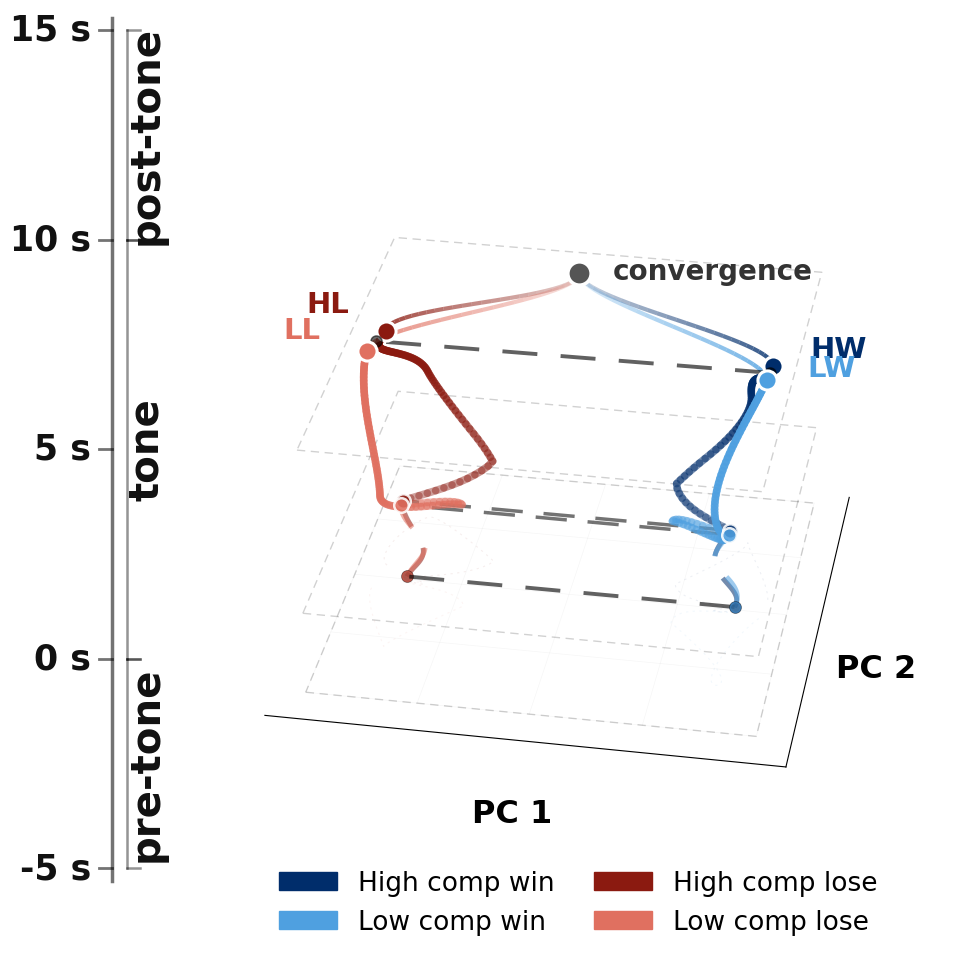

In [7]:
%matplotlib inline
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
 
CONDITIONS = [
    dict(id='HW', outcome= 1, comp= 1, color='#002D6B', label='High comp win'),
    dict(id='LW', outcome= 1, comp=-1, color='#4fa0e0', label='Low comp win'),
    dict(id='HL', outcome=-1, comp= 1, color='#8b1a10', label='High comp lose'),
    dict(id='LL', outcome=-1, comp=-1, color='#e07060', label='Low comp lose'),
]
 
def ease(x):
    x = np.clip(x, 0, 1)
    return np.where(x < 0.5, 2*x*x, 1 - (-2*x+2)**2/2)
 
def smooth(x):
    x = np.clip(x, 0, 1)
    return x*x*(3 - 2*x)
 
def lerp(a, b, t):
    return a + (b - a) * t
 
CONV  = np.array([0.04, 0.03])
N_PRE  = 40
N_TONE = 80
N_POST = 30
 
# Z is TIME. Map uniformly: -5s=Z_PRE, 0s=0, 10s=Z_TONE_END, 15s=Z_TOP
# Use a simple linear scale so everything is in the same 3D box
# Let's use actual seconds as z directly
Z_PRE_S  = -5.0
Z_BOT_S  =  0.0
Z_MID_S  = 10.0
Z_TOP_S  = 15.0
 
def make_trajectory(cond):
    outcome, comp = cond['outcome'], cond['comp']
    pts = []
    ps = np.array([outcome * 0.72, 0.0])
    for i in range(N_PRE):
        t = i / (N_PRE - 1)
        dx = 0.05 * np.sin(t * np.pi * 1.8 + outcome * 0.9)
        dy = 0.03 * np.cos(t * np.pi * 1.4 + comp * 0.7)
        pts.append([ps[0] + dx, ps[1] + dy])
    pre_end = np.array(pts[-1])
    for i in range(N_TONE):
        t = i / (N_TONE - 1)
        entry_blend = min(t / 0.15, 1.0)
        outcome_spread = 0.30 + 0.52 * ease(min(t * 2.2, 1))
        comp_spread = (0.10 + 0.52 * ease(t / 0.45)) if t < 0.45 else lerp(0.62, 0.04, smooth((t - 0.45) / 0.55))
        dx = 0.08 * np.sin(t * np.pi * 2.1 + outcome * 1.1 + comp * 0.4)
        dy = 0.06 * np.cos(t * np.pi * 1.7 + comp * 1.2 + outcome * 0.5)
        tx = outcome * outcome_spread + dx
        ty = comp * comp_spread + dy
        pts.append([lerp(pre_end[0], tx, entry_blend), lerp(pre_end[1], ty, entry_blend)])
    last = np.array(pts[-1])
    for i in range(N_POST):
        t = (i + 1) / N_POST
        et = smooth(t)
        pts.append([lerp(last[0], CONV[0], et), lerp(last[1], CONV[1], et)])
    return np.array(pts)
 
trajs = {c['id']: make_trajectory(c) for c in CONDITIONS}
 
z_pre  = np.linspace(Z_PRE_S,  Z_BOT_S, N_PRE)
z_tone = np.linspace(Z_BOT_S,  Z_MID_S, N_TONE)
z_post = np.linspace(Z_MID_S,  Z_TOP_S, N_POST + 1)[1:]
 
# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 10), facecolor='white')
ax = fig.add_axes([0.15, 0.07, 0.80, 0.88], projection='3d', facecolor='white')
ax.view_init(elev=30, azim=-80)
 
# ── Faint grid at Z_PRE_S (bottom of time axis) ──────────────────────────────
for g in np.linspace(-1, 1, 5):
    ax.plot([g,g],[-1,1],[Z_PRE_S,Z_PRE_S], color='gray', alpha=0.07, lw=0.5)
    ax.plot([-1,1],[g,g],[Z_PRE_S,Z_PRE_S], color='gray', alpha=0.07, lw=0.5)
 
# Plane outlines at -5s, 0s, 10s
for z_plane in [Z_PRE_S, Z_BOT_S, Z_MID_S]:
    cx=[-1,1,1,-1,-1]; cy=[-1,-1,1,1,-1]; cz=[z_plane]*5
    ax.plot(cx, cy, cz, color='black', alpha=0.18, lw=1.0, linestyle='--', dashes=(6,4))
 
# ── Dashed square at 0s ───────────────────────────────────────────────────────
sq_ids = ['HW','HL','LL','LW','HW']
sx = [trajs[i][N_PRE,0] for i in sq_ids]
sy_sq = [trajs[i][N_PRE,1] for i in sq_ids]
sz = [Z_BOT_S]*5
ax.plot(sx, sy_sq, sz, color='black', alpha=0.55, lw=2.5, linestyle='--', dashes=(9,6))
 
# ── Centroid lines ────────────────────────────────────────────────────────────
def centroid_line(z_val, idx):
    hw=trajs['HW'][idx]; lw=trajs['LW'][idx]
    hl=trajs['HL'][idx]; ll=trajs['LL'][idx]
    wc=(hw+lw)/2; lc=(hl+ll)/2
    ax.plot([wc[0],lc[0]], [wc[1],lc[1]], [z_val,z_val],
            color='black', alpha=0.62, lw=2.8, linestyle='--', dashes=(9,6), zorder=6)
    for pt in [wc, lc]:
        ax.scatter([pt[0]],[pt[1]],[z_val], color='black', s=65,
                   alpha=0.58, depthshade=False, zorder=7)
 
centroid_line(Z_PRE_S, 0)
centroid_line(Z_MID_S, N_PRE + N_TONE - 1)
 
# ── Trajectories ──────────────────────────────────────────────────────────────
for cond in CONDITIONS:
    cid   = cond['id']
    color = cond['color']
    pts   = trajs[cid]
 
    # shadow on bottom plane
    ax.plot(pts[:N_PRE+N_TONE,0], pts[:N_PRE+N_TONE,1],
            np.full(N_PRE+N_TONE, Z_PRE_S),
            color=color, alpha=0.07, lw=0.8, linestyle='--', dashes=(2,4))
 
    # pre-tone — dashed
    ax.plot(pts[:N_PRE,0], pts[:N_PRE,1], z_pre,
            color=color, alpha=0.55, lw=3.5, linestyle='--', dashes=(7,5))
 
    # tone — solid, alpha gradient
    for i in range(N_TONE-1):
        alpha = 0.40 + 0.60*(i/(N_TONE-1))
        ax.plot(pts[N_PRE+i:N_PRE+i+2,0],
                pts[N_PRE+i:N_PRE+i+2,1],
                z_tone[i:i+2],
                color=color, alpha=alpha, lw=5.5, solid_capstyle='round')
 
    # post-tone — dashed, fading
    for i in range(N_POST-1):
        alpha = lerp(0.85, 0.08, i/(N_POST-1))
        ax.plot(pts[N_PRE+N_TONE+i:N_PRE+N_TONE+i+2,0],
                pts[N_PRE+N_TONE+i:N_PRE+N_TONE+i+2,1],
                z_post[i:i+2],
                color=color, alpha=alpha, lw=3.0, linestyle='--', dashes=(6,5))
 
    # dots
    ax.scatter([pts[0,0]],[pts[0,1]],[Z_PRE_S],
               color=color, s=55, alpha=0.50, depthshade=False)
    ax.scatter([pts[N_PRE,0]],[pts[N_PRE,1]],[Z_BOT_S],
               color=color, s=110, alpha=0.88,
               edgecolors='white', linewidths=1.8, depthshade=False, zorder=8)
    ax.scatter([pts[N_PRE+N_TONE-1,0]],[pts[N_PRE+N_TONE-1,1]],[Z_MID_S],
               color=color, s=190, alpha=1.0,
               edgecolors='white', linewidths=2.2, depthshade=False, zorder=9)
 
    # label at 10s
    lx = pts[N_PRE+N_TONE-1,0]*1.32
    ly = pts[N_PRE+N_TONE-1,1]*1.32
    ax.text(lx, ly, Z_MID_S+0.3, cid,
            color=color, fontsize=21, fontweight='bold', ha='center', va='bottom')
 
# convergence
ax.scatter([CONV[0]],[CONV[1]],[Z_TOP_S], color='#555', s=280,
           edgecolors='white', linewidths=2.5, depthshade=False, zorder=9)
ax.text(CONV[0]+0.15, CONV[1], Z_TOP_S+0.3, 'convergence',
        color='#333', fontsize=20, fontweight='bold', va='center')
 
# ── Axes cosmetics ────────────────────────────────────────────────────────────
ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15)
ax.set_zlim(Z_PRE_S - 0.5, Z_TOP_S + 0.5)
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False; pane.set_edgecolor('none')
ax.grid(False)
ax.zaxis.line.set_color((1,1,1,0))
ax.set_xlabel('PC 1', fontsize=23, fontweight='bold', labelpad=14)
ax.set_ylabel('PC 2', fontsize=23, fontweight='bold', labelpad=14)
ax.set_zlabel('')
 
# ── Z axis in a separate 2D axes panel (left strip) ──────────────────────────
ax2 = fig.add_axes([0.01, 0.07, 0.13, 0.88])
ax2.set_xlim(0, 1)
ax2.set_ylim(Z_PRE_S - 0.5, Z_TOP_S + 0.5)
ax2.axis('off')
 
# vertical line
ax2.plot([0.72, 0.72], [Z_PRE_S - 0.3, Z_TOP_S + 0.3],
         color='black', alpha=0.55, lw=2.5, transform=ax2.transData)
 
# ticks + labels
ticks = [(Z_PRE_S,'-5 s'),(Z_BOT_S,'0 s'),(5.0,'5 s'),(Z_MID_S,'10 s'),(Z_TOP_S,'15 s')]
for z_val, lbl in ticks:
    ax2.plot([0.62, 0.72], [z_val, z_val],
             color='black', alpha=0.55, lw=2.0, transform=ax2.transData)
    ax2.text(0.56, z_val, lbl,
             fontsize=25, fontweight='bold', color='#111',
             ha='right', va='center', transform=ax2.transData)
 
# Phase brackets + rotated labels
phases = [(Z_PRE_S, Z_BOT_S, 'pre-tone'), (Z_BOT_S, Z_MID_S, 'tone'), (Z_MID_S, Z_TOP_S, 'post-tone')]
for z0, z1, name in phases:
    zm = (z0 + z1) / 2
    bx = 0.84
    ax2.plot([bx, bx+0.10], [z0, z0], color='black', alpha=0.42, lw=1.8, transform=ax2.transData)
    ax2.plot([bx, bx],      [z0, z1], color='black', alpha=0.42, lw=1.8, transform=ax2.transData)
    ax2.plot([bx, bx+0.10], [z1, z1], color='black', alpha=0.42, lw=1.8, transform=ax2.transData)
    ax2.text(0.99, zm, name,
             fontsize=29, fontweight='bold', color='#111',
             ha='center', va='center', rotation=90,
             transform=ax2.transData)
 
# ── Legend ────────────────────────────────────────────────────────────────────
handles = [mpatches.Patch(color=c['color'], label=c['label']) for c in CONDITIONS]
fig.legend(handles=handles,
           loc='lower center', bbox_to_anchor=(0.57, 0.0),
           ncol=2, fontsize=19, frameon=False, handlelength=2.2, columnspacing=1.5)
plt.show()
# plt.savefig('rce_test/tone_trajectory.png',
#             dpi=180, bbox_inches='tight', facecolor='white')
# print("saved")